# Module Load

In [1]:
from __future__ import annotations

import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Data Load and clean

In [2]:


# Load VAS labels CSV
file_path = r"C:\Users\Patrick\Gutbrain_R\data\GUTBRAIN-VASScale_DATA_LABELS_2025-11-28_0927.csv"

df_vas_labels = pd.read_csv(file_path, low_memory=False)

print(f"Loaded df_vas_labels from: {file_path} shape: {df_vas_labels.shape}")
print("Columns:", list(df_vas_labels.columns))
print("\nFirst few rows:")
print(df_vas_labels.head())

# Inspect likely key columns
for col in df_vas_labels.columns:
    if any(x in col.lower() for x in ["id", "participant", "record", "session", "event", "visite"]):
        print(f"\n{col}: {df_vas_labels[col].nunique()} unique values")
        print(f"Sample values: {df_vas_labels[col].unique()[:5]}")

# Prepare for merge with df
df_vas_labels = df_vas_labels.copy()
df_vas_labels["id_participant"] = df_vas_labels["Numéro participant"].astype(str).str.lower().str.strip()

def map_session(row):
    event = row["Event Name"]
    participant = row["id_participant"]

    if "rgc" in str(participant).lower():
        session_map = {
            "Baseline": 1,
            "4 mois": "x",
            "12 mois": 2,
            "24 mois": None
        }
    else:
        session_map = {
            "Baseline": 1,
            "4 mois": 2,
            "12 mois": 3,
            "24 mois": 4
        }

    return session_map.get(event)

df_vas_labels["session"] = df_vas_labels.apply(map_session, axis=1)
df_vas_labels["vas_hunger_before"] = df_vas_labels["VAS début IRM"]
df_vas_labels["vas_hunger_after"] = df_vas_labels["VAS fin IRM"]

print("\nPrepared df_vas_labels for merging:")
print(df_vas_labels[["id_participant", "Event Name", "session", "vas_hunger_before", "vas_hunger_after"]].head(15))

rgc_mask = df_vas_labels["id_participant"].str.lower().str.contains("rgc", na=False)
print(f"\nRGC participants: {df_vas_labels[rgc_mask]['id_participant'].nunique()}")
print(f"Non-RGC participants: {df_vas_labels[~rgc_mask]['id_participant'].nunique()}")
print(f"Sessions marked as 'x': {(df_vas_labels['session'] == 'x').sum()}")

missing_sessions = df_vas_labels["session"].isna().sum()
if missing_sessions > 0:
    print(f"\nWarning: {missing_sessions} rows have unmapped sessions")

print(f"\n{'='*70}")
print("Summary for: df_vas_labels (before merge)")
print(f"{'='*70}\n")

df_vas_labels.info(verbose=True, show_counts=True)

vas_col_info = pd.DataFrame({
    "dtype": df_vas_labels.dtypes.astype(str),
    "non_null": df_vas_labels.count(),
    "n_unique(incl_NaN)": df_vas_labels.nunique(dropna=False),
    "pct_missing": (df_vas_labels.isna().mean() * 100).round(2),
    "sample_values_first5": df_vas_labels.apply(lambda s: s.dropna().unique()[:5].tolist())
})

vas_desc_stats = df_vas_labels.describe(include="all").T

print("\nColumn Information:")
print(vas_col_info)
print("\nDescriptive Statistics:")
print(vas_desc_stats)

Loaded df_vas_labels from: C:\Users\Patrick\Gutbrain_R\data\GUTBRAIN-VASScale_DATA_LABELS_2025-11-28_0927.csv shape: (446, 9)
Columns: ['Record ID', 'Event Name', 'Numéro participant', 'Date IRM', 'Âge au scan', 'VAS début IRM', 'Heure VAS faim début', 'VAS fin IRM', 'Heure VAS faim fin']

First few rows:
   Record ID Event Name Numéro participant   Date IRM  Âge au scan  \
0          1   Baseline             RCX096   9/8/2016         55.1   
1          1     4 mois             RCX096  1/31/2017         55.5   
2          1    12 mois             RCX096  10/3/2017         56.2   
3          1    24 mois             RCX096  10/4/2018         57.2   
4          2   Baseline             RND001   9/2/2016         46.1   

   VAS début IRM Heure VAS faim début  VAS fin IRM Heure VAS faim fin  
0            5.0                11:30          5.0                NaN  
1            4.7                10:34          4.5              11:34  
2            0.0                 9:41          5.0      

In [3]:
# Load the CSV file into a DataFrame
file_path = 'C:\\Users\\Patrick\\Gutbrain_R\\data\\final_merged_quest.csv'
df = pd.read_csv(file_path, low_memory=False)


# Fill NaN values in the 'sexe' column based on the same participant and session 1
df['sexe'] = df.groupby(['id_participant', 'session'])['sexe'].transform(lambda x: x.ffill().bfill())

# If there are still NaN values, fill them based on the same participant across all sessions
df['type_chx'] = df.groupby('id_participant')['type_chx'].transform(lambda x: x.ffill().bfill())

# If there are still NaN values, fill them based on the same participant and session 1
df['sexe'] = df.groupby('id_participant')['sexe'].transform(lambda x: x.ffill().bfill())

df['sexeF'] = df['sexe'].apply(lambda x: 1 if x == 2 else 0)

# Drop the column 'imc_recherche_y_mean'
df.drop(columns=['imc_recherche_y'], inplace=True)

# Rename the column 'imc_recherche_x_mean' to 'imc_recherche_mean'
df.rename(columns={'imc_recherche_x': 'imc_recherche'}, inplace=True)

# Create the IMC_baseline column
df['IMC_baseline'] = df.groupby('id_participant', observed=False)['imc_recherche'].transform(lambda x: x.iloc[0])

df.rename(columns={'Prix pour la portion calculee par Anais': 'prix_par_portion'}, inplace=True)

# Drop rows where 'onset_bid' is NaN
df.dropna(subset=['onset_bid'], inplace=True)

# Remove rows where 'bid' is NaN
df.dropna(subset=['bid'], inplace=True)

# python
age_baseline = (df.loc[df['session'] == 1]
                  .drop_duplicates('id_participant')
                  .set_index('id_participant')['age'])
df['age_baseline'] = df['id_participant'].map(age_baseline)
# optional fallback to first non-NA if session==1 missing:
mask_missing = df['age_baseline'].isna()
df.loc[mask_missing, 'age_baseline'] = df.loc[mask_missing].groupby('id_participant')['age'].transform('first')

# Remove rows where 'like' is NaN, then where 'known' is NaN
before = len(df)
df.dropna(subset=['like'], inplace=True)
dropped_like = before - len(df)

before = len(df)
df.dropna(subset=['known'], inplace=True)
dropped_known = before - len(df)

print(f"Dropped {dropped_like} rows with NA in 'like' and {dropped_known} rows with NA in 'known' (remaining {len(df)} rows)")


# create centered versions of all numeric (quantitative) columns, skip any already centered
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols = [c for c in numeric_cols if not c.endswith('_centered')]

for col in numeric_cols:
    df[col + '_centered'] = df[col] - df[col].mean()

print(f"Created {len(numeric_cols)} centered columns.")
df[[c + '_centered' for c in numeric_cols]].head()

# ensure type_chx is treated as an object (not numeric)
df['type_chx'] = df['type_chx'].astype(object)

# if a centered numeric version was created earlier, remove it
if 'type_chx_centered' in df.columns:
    df.drop(columns=['type_chx_centered'], inplace=True)

# update numeric_cols list (if present) so it no longer treats type_chx as numeric
if 'numeric_cols' in globals() and isinstance(numeric_cols, list):
    numeric_cols = [c for c in numeric_cols if c != 'type_chx']

print("type_chx dtype:", df['type_chx'].dtype)

df.rename(columns={'Prix Total des aliments montres_centered': 'prix_total_aliments_centered'}, inplace=True)


C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\4200499347.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['IMC_baseline'] = df.groupby('id_participant', observed=False)['imc_recherche'].transform(lambda x: x.iloc[0])
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\4200499347.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['age_baseline'] = df['id_participant'].map(age_baseline)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\4200499347.py:60: PerformanceWarning: DataFrame is highly fragmented.  This 

Dropped 13 rows with NA in 'like' and 22 rows with NA in 'known' (remaining 43569 rows)
Created 121 centered columns.
type_chx dtype: object


In [4]:
# Now merge with df - merge both numeric sessions AND 'x' sessions
# First merge numeric sessions
df_vas_numeric = df_vas_labels[df_vas_labels['session'] != 'x'].copy()

# Convert session to object/string in both dataframes for merging
df['session'] = df['session'].astype(str)
df_vas_numeric['session'] = df_vas_numeric['session'].astype(str)

df = df.merge(
    df_vas_numeric[['id_participant', 'session', 'vas_hunger_before', 'vas_hunger_after', 'Heure VAS faim début', 'Heure VAS faim fin']],
    on=['id_participant', 'session'],
    how='left'
)

# Now merge 'x' sessions separately
df_vas_x = df_vas_labels[df_vas_labels['session'] == 'x'].copy()
if len(df_vas_x) > 0:
    # For rows in df where session is 'x', merge on id_participant only
    df = df.merge(
        df_vas_x[['id_participant', 'vas_hunger_before', 'vas_hunger_after', 'Heure VAS faim début', 'Heure VAS faim fin']],
        on='id_participant',
        how='left',
        suffixes=('', '_x_temp')
    )
    
    # For rows where session == 'x' in df, use the _x_temp columns
    x_mask = df['session'] == 'x'
    for col in ['vas_hunger_before', 'vas_hunger_after', 'Heure VAS faim début', 'Heure VAS faim fin']:
        if col + '_x_temp' in df.columns:
            df.loc[x_mask, col] = df.loc[x_mask, col + '_x_temp']
            df.drop(columns=[col + '_x_temp'], inplace=True)

# Ensure 'run' is treated as an object (categorical), not numeric
if 'run' in df.columns:
    df['run'] = df['run'].astype(object)
    # If a centered numeric version was created earlier, remove it
    if 'run_centered' in df.columns:
        df.drop(columns=['run_centered'], inplace=True)
    print("'run' column converted to object dtype")

print(f"\n{'='*70}")
print(f"Merge Results")
print(f"{'='*70}")
print(f"Final df shape: {df.shape}")
print(f"\nRows with vas_hunger_before data: {df['vas_hunger_before'].notna().sum()}")
print(f"Rows with vas_hunger_after data: {df['vas_hunger_after'].notna().sum()}")
print(f"VAS data for session='x': {df[df['session']=='x']['vas_hunger_before'].notna().sum()}")
if 'run' in df.columns:
    print(f"'run' dtype: {df['run'].dtype}")

'run' column converted to object dtype

Merge Results
Final df shape: (43569, 254)

Rows with vas_hunger_before data: 41455
Rows with vas_hunger_after data: 39008
VAS data for session='x': 2698
'run' dtype: object


## Integrate new pricing and visual properties

In [5]:

df_food = pd.read_csv(r"C:\Users\Patrick\Gutbrain_R\data\gutbrain_food_final_merged_df.tsv", sep="\t")


In [6]:
# Filter df_food to keep only session = 1, then merge with df on picture column

if 'df_food' in globals() and df_food is not None:
    # Filter df_food to keep only session = 1
    df_food_session1 = df_food[df_food['session'] == 1].copy()
    
    print(f"df_food before filtering: {len(df_food)} rows")
    print(f"df_food after filtering (session=1): {len(df_food_session1)} rows")
    print(f"Unique pictures in df_food_session1: {df_food_session1['picture_clean'].nunique()}")
    
    # Identify columns that already exist in df (will be excluded from merge)
    df_cols = set(df.columns)
    df_food_cols = set(df_food_session1.columns) - {'picture_x', 'picture_y', 'picture_clean', 'session'}
    duplicate_cols = df_cols.intersection(df_food_cols)
    
    print(f"\nColumns that exist in both dataframes (will be excluded): {len(duplicate_cols)}")
    if len(duplicate_cols) > 0:
        print(f"  Excluded columns: {sorted(list(duplicate_cols))[:20]}")
    
    # Select columns to merge (excluding picture columns AND duplicate columns)
    cols_to_merge = [col for col in df_food_session1.columns 
                     if col not in ['picture_x', 'picture_y', 'session'] and col not in duplicate_cols]
    # Always include picture_clean as the merge key
    if 'picture_clean' not in cols_to_merge:
        cols_to_merge.append('picture_clean')
    
    print(f"\nColumns to merge from df_food_session1: {len(cols_to_merge) - 1}")  # -1 for picture_clean
    print(f"Sample columns: {[c for c in cols_to_merge if c != 'picture_clean'][:10]}")
    
    # Rename picture_clean to picture for merging
    df_food_session1_renamed = df_food_session1[cols_to_merge].rename(columns={'picture_clean': 'picture'})
    
    # Check merge key overlap
    df_pictures = set(df['picture'].dropna().unique())
    df_food_pictures = set(df_food_session1_renamed['picture'].dropna().unique())
    overlap = df_pictures.intersection(df_food_pictures)
    
    print(f"\nMerge key overlap:")
    print(f"  Unique pictures in df: {len(df_pictures)}")
    print(f"  Unique pictures in df_food_session1: {len(df_food_pictures)}")
    print(f"  Common pictures: {len(overlap)} ({len(overlap)/len(df_pictures)*100:.1f}% coverage)")
    
    # Store original shape
    original_shape = df.shape
    
    # Merge with df
    df = df.merge(
        df_food_session1_renamed,
        on='picture',
        how='left',
        suffixes=('', '_food')
    )
    
    print(f"\nMerge completed:")
    print(f"  df shape before merge: {original_shape}")
    print(f"  df shape after merge: {df.shape}")
    print(f"  New columns added: {df.shape[1] - original_shape[1]}")
    
    # Show sample of merged data
    new_cols = [col for col in df.columns if col.endswith('_food') or 
                (col in df_food_session1_renamed.columns and col not in ['picture'])]
    print(f"\nSample of new columns (first 5): {new_cols[:5]}")
    
    # Check for successful merges
    sample_new_col = [col for col in new_cols if col != 'picture']
    if sample_new_col:
        merged_count = df[sample_new_col[0]].notna().sum()
        print(f"\nRows with data from df_food: {merged_count} ({merged_count/len(df)*100:.1f}%)")
    
else:
    print("df_food not found or not loaded yet")

df_food before filtering: 280 rows
df_food after filtering (session=1): 70 rows
Unique pictures in df_food_session1: 70

Columns that exist in both dataframes (will be excluded): 124
  Excluded columns: ["Calorie montree (Selon l'image)", 'Commentaire.1', 'DDT_k_ICR_mean', 'DDT_k_cons_mean', 'DDT_kmean', "Grammes montrés (Selon l'image)", 'IMC_baseline', 'MCQ_large_ICR', 'MCQ_large_cons', 'MCQ_large_k', 'MCQ_medium_ICR', 'MCQ_medium_cons', 'MCQ_medium_k', 'MCQ_seq_large', 'MCQ_seq_medium', 'MCQ_seq_small', 'MCQ_small_ICR', 'MCQ_small_cons', 'MCQ_small_k', 'Moyenne Portion']

Columns to merge from df_food_session1: 18
Sample columns: ['Moyenne Densite', 'filename', 'width', 'height', 'mean_color_r', 'mean_color_g', 'mean_color_b', 'brightness', 'contrast', 'num_object_pixels']

Merge key overlap:
  Unique pictures in df: 70
  Unique pictures in df_food_session1: 70
  Common pictures: 70 (100.0% coverage)

Merge completed:
  df shape before merge: (43569, 254)
  df shape after merge: (43

In [7]:
# Create grand-mean centered versions of new numeric columns from df_food merge

if 'df_food' in globals() and df_food is not None:
    # Get list of new columns added from df_food (excluding duplicates and picture)
    new_cols = [col for col in df.columns if col.endswith('_food') or 
                (col in df_food_session1_renamed.columns and col not in ['picture'])]
    
    # Filter to only numeric columns
    numeric_new_cols = [col for col in new_cols if pd.api.types.is_numeric_dtype(df[col])]
    
    print(f"Creating grand-mean centered versions for {len(numeric_new_cols)} new numeric columns")
    
    # Create centered versions
    for col in numeric_new_cols:
        centered_col_name = col + '_centered'
        df[centered_col_name] = df[col] - df[col].mean()
    
    print(f"\nGrand-mean centering completed!")
    print(f"Created {len(numeric_new_cols)} new centered columns")
    
    # Show sample of centered columns
    centered_col_names = [col + '_centered' for col in numeric_new_cols]
    print(f"\nSample of centered columns (first 10):")
    for col in centered_col_names[:10]:
        if col in df.columns:
            print(f"  {col}: mean = {df[col].mean():.10f}")
    
    # Verify centering
    print(f"\nVerification - all centered columns should have mean ≈ 0:")
    centered_means = df[centered_col_names].mean()
    max_deviation = centered_means.abs().max()
    print(f"Maximum absolute deviation from 0: {max_deviation:.10e}")
    
else:
    print("df_food not found or merge not completed yet")

Creating grand-mean centered versions for 17 new numeric columns

Grand-mean centering completed!
Created 17 new centered columns

Sample of centered columns (first 10):
  Moyenne Densite_centered: mean = -0.0000000000
  width_centered: mean = 0.0000000000
  height_centered: mean = 0.0000000000
  mean_color_r_centered: mean = 0.0000000000
  mean_color_g_centered: mean = 0.0000000000
  mean_color_b_centered: mean = 0.0000000000
  brightness_centered: mean = -0.0000000000
  contrast_centered: mean = -0.0000000000
  num_object_pixels_centered: mean = 0.0000000000
  width_zscore_centered: mean = -0.0000000000

Verification - all centered columns should have mean ≈ 0:
Maximum absolute deviation from 0: 6.5837488348e-12


C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\3355968074.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[centered_col_name] = df[col] - df[col].mean()


In [8]:
# Fix column names: rename 'Prix/gramme' to 'prix_gramme' and 'Prix/gramme_centered' to 'prix_gramme_centered'

# Check if the columns exist with the slash (case-sensitive check)
rename_dict = {}

for col in df.columns:
    if col == 'Prix/gramme':
        rename_dict[col] = 'prix_gramme'
    elif col == 'Prix/gramme_centered':
        rename_dict[col] = 'prix_gramme_centered'

if rename_dict:
    df.rename(columns=rename_dict, inplace=True)
    print(f"Renamed {len(rename_dict)} column(s):")
    for old, new in rename_dict.items():
        print(f"  '{old}' -> '{new}'")
else:
    print("No columns found matching 'Prix/gramme' or 'Prix/gramme_centered'")

# Verify the columns exist now
prix_cols = [col for col in df.columns if 'prix_gramme' in col.lower()]
print(f"\nColumns containing 'prix_gramme': {prix_cols}")

# Verify mean of centered version
if 'prix_gramme_centered' in df.columns:
    print(f"Mean of prix_gramme_centered: {df['prix_gramme_centered'].mean():.10f}")

Renamed 2 column(s):
  'Prix/gramme' -> 'prix_gramme'
  'Prix/gramme_centered' -> 'prix_gramme_centered'

Columns containing 'prix_gramme': ['prix_gramme', 'prix_gramme_centered']
Mean of prix_gramme_centered: -0.0000000000


# Functions

## Mixed LM function

In [9]:
def fit_lmm(df,
            formula=None,
            group_col='id_participant',
            re_formula='1',
            reml=True,
            standardize=None,
            plot=True,
            verbose=True,
            contrasts=None,
            session_summary_vars=None,
            session_summary_col='session',
            print_session_summary=False,
            robust_cov: str | None = None,
            dropna=True):
    """
    Fit a linear mixed model and produce diagnostics.

    Parameters:
    - dropna: bool, default True. If True, drops rows with NaN values in any column used in the formula.
    - robust_cov: None or string passed to MixedLMResults.get_robustcov_results(cov_type=...)
        e.g. 'HC0','HC1','HC2','HC3' or 'cluster' (see statsmodels docs).
        If provided, the function will attempt to compute robust covariance results and
        use that results object for parameter summaries, contrasts and cov_params.
    Returns: (results_obj, diagnostics) where results_obj is MixedLMResults or robust wrapper.
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import statsmodels.formula.api as smf
    from statsmodels.stats.diagnostic import het_breuschpagan
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    from scipy import stats

    df_local = df.copy()
    
    # Drop rows with NaN if requested
   
    if dropna:
        initial_rows = len(df_local)
        import re

        if formula is not None:
            formula_vars = re.findall(r'\b[a-zA-Z_][a-zA-Z0-9_]*\b', formula)
            all_cols = list(dict.fromkeys(formula_vars + [group_col]))
            cols_to_check = [c for c in all_cols if c in df_local.columns]

            # Keep only rows with no NaN in relevant columns
            nan_mask = df_local[cols_to_check].isna().any(axis=1)

            if {'session', 'id_participant'}.issubset(df_local.columns):
                nan_df = df_local.loc[nan_mask, cols_to_check].isna()

                dropped_info = df_local.loc[nan_mask, ['session', 'id_participant']].copy()
                dropped_info['nan_columns'] = nan_df.apply(
                    lambda row: ', '.join([col for col in row.index if row[col]]),
                    axis=1
                )

                dropped_pairs = (
                    dropped_info[['session', 'id_participant', 'nan_columns']]
                    .drop_duplicates()
                    .sort_values(['session', 'id_participant'])
                    .reset_index(drop=True)
                )

                print("Dropped session / id_participant pairs and NaN source columns:")
                print(dropped_pairs)
                print(f"Number of dropped pairs: {len(dropped_pairs)}")

            df_local = df_local.dropna(subset=cols_to_check)
            dropped_rows = initial_rows - len(df_local)

            if verbose and dropped_rows > 0:
                print(f"Dropped {dropped_rows} rows with NaN values. Remaining: {len(df_local)} rows.")


    # optional standardization
    if standardize:
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        cols = list(standardize)
        df_local[[c + '_z' for c in cols]] = scaler.fit_transform(df_local[cols])
        # replace column names in formula and re_formula if user included originals
        for c in cols:
            if formula is not None:
                formula = formula.replace(c, c + '_z')
            if re_formula is not None:
                re_formula = re_formula.replace(c, c + '_z')

    # Fit mixed model (use provided re_formula; pass '1' to disable random slopes)
    mixed = smf.mixedlm(formula, df_local, groups=df_local[group_col], re_formula=re_formula)
    mixed_fit = mixed.fit(reml=reml, warn_convergence=False)

    diagnostics = {}
    diagnostics['summary'] = mixed_fit.summary()

    resid = mixed_fit.resid
    fitted = mixed_fit.fittedvalues
    diagnostics['residuals'] = resid
    diagnostics['fitted_values'] = fitted

    if plot:
        sns.scatterplot(x=fitted, y=resid)
        plt.xlabel('Fitted values')
        plt.ylabel('Residuals')
        plt.title('Residuals vs Fitted values')
        plt.axhline(0, color='grey', linestyle='--', linewidth=0.7)
        plt.show()

        from statsmodels.graphics.gofplots import qqplot
        qqplot(resid, line='45')
        plt.title('QQ-plot of Residuals')
        plt.show()

    # Breusch-Pagan test (uses model.exog)
    try:
        bp_test = het_breuschpagan(resid, mixed_fit.model.exog)
        diagnostics['breusch_pagan'] = bp_test
        bp_pvalue = bp_test[1]
    except Exception as e:
        diagnostics['breusch_pagan'] = ('error', str(e))
        bp_pvalue = None

    # Shapiro-Wilk (with warning for large samples)
    try:
        n_obs = len(resid)
        if n_obs <= 5000:
            sh = stats.shapiro(resid)
            diagnostics['shapiro'] = sh
        else:
            # Use Anderson-Darling for large samples
            from scipy.stats import anderson
            ad_result = anderson(resid, dist='norm')
            diagnostics['shapiro'] = ('skipped', f'N={n_obs} > 5000, using Anderson-Darling instead')
            diagnostics['anderson_darling'] = ad_result
            if verbose:
                print(f"\nAnderson-Darling test (N={n_obs}):")
                print(f"  Statistic: {ad_result.statistic:.4f}")
                print(f"  Critical values: {ad_result.critical_values}")
                print(f"  Significance levels: {ad_result.significance_level}")
    except Exception as e:
        diagnostics['shapiro'] = ('error', str(e))

    # VIF
    try:
        exog = mixed_fit.model.exog
        names = mixed_fit.model.exog_names
        vif_df = pd.DataFrame({'feature': names,
                               'VIF': [variance_inflation_factor(exog, i) for i in range(exog.shape[1])]})
        diagnostics['vif'] = vif_df
    except Exception as e:
        diagnostics['vif'] = ('error', str(e))

    diagnostics['aic'] = mixed_fit.aic if hasattr(mixed_fit, 'aic') else (2 * len(mixed_fit.params) - 2 * mixed_fit.llf)
    diagnostics['bic'] = mixed_fit.bic if hasattr(mixed_fit, 'bic') else (np.log(mixed_fit.nobs) * len(mixed_fit.params) - 2 * mixed_fit.llf)
    diagnostics['llf'] = mixed_fit.llf
    diagnostics['nobs'] = mixed_fit.nobs
    diagnostics['params'] = mixed_fit.params

    # Wald tests
    try:
        # 1) Term-wise global tests
        wald_terms = mixed_fit.wald_test_terms(skip_single=False, scalar=True)
        diagnostics['wald_test_terms'] = wald_terms

        # 2) One omnibus Wald over all fixed effects
        fe_names = list(mixed_fit.model.exog_names)
        k_fe = len(fe_names)
        p_full = len(mixed_fit.params)  # includes variance params too

        R_all = np.zeros((k_fe, p_full), dtype=float)
        R_all[:, :k_fe] = np.eye(k_fe)
        wald_all = mixed_fit.wald_test(R_all, scalar=True)
        diagnostics['wald_test_all_fixed_effects'] = wald_all

        # 3) Omnibus Wald excluding intercept
        wald_no_intercept = None
        if 'Intercept' in fe_names and k_fe > 1:
            keep_idx = [i for i, n in enumerate(fe_names) if n != 'Intercept']
            R_no_intercept = np.zeros((len(keep_idx), p_full), dtype=float)
            for r, i in enumerate(keep_idx):
                R_no_intercept[r, i] = 1.0
            wald_no_intercept = mixed_fit.wald_test(R_no_intercept, scalar=True)
            diagnostics['wald_test_all_predictors_no_intercept'] = wald_no_intercept

        if verbose:
            print("\n--- Wald Test (Global Effect by Term) ---")
            print(wald_terms)

            print("\n--- Wald Test (Global Effect: ALL Fixed Coefficients) ---")
            print(wald_all)

            if wald_no_intercept is not None:
                print("\n--- Wald Test (Global Effect: ALL Predictors, No Intercept) ---")
                print(wald_no_intercept)

    except Exception as e:
        diagnostics['wald_test_terms'] = ('error', str(e))
        diagnostics['wald_test_all_fixed_effects'] = ('error', str(e))
        diagnostics['wald_test_all_predictors_no_intercept'] = ('error', str(e))
        if verbose:
            print("Wald test failed:", e)

    # R-squared for the mixed model
    try:
        import patsy

        def calculate_r_squared_components(fit):
            fixed_fitted = fit.model.exog @ fit.fe_params
            fixed_variance = float(np.var(fixed_fitted))

            random_covariance = np.atleast_2d(np.asarray(fit.cov_re))
            random_variance = float(np.trace(random_covariance))

            residual_variance = float(fit.scale)
            total_variance = (
                fixed_variance
                + random_variance
                + residual_variance
            )

            if total_variance <= 0:
                return {
                    'marginal': np.nan,
                    'conditional': np.nan,
                    'fixed_variance': fixed_variance,
                    'random_variance': random_variance,
                    'residual_variance': residual_variance,
                    'total_variance': total_variance
                }

            return {
                'marginal': fixed_variance / total_variance,
                'conditional': (
                    fixed_variance + random_variance
                ) / total_variance,
                'fixed_variance': fixed_variance,
                'random_variance': random_variance,
                'residual_variance': residual_variance,
                'total_variance': total_variance
            }

        global_r2 = calculate_r_squared_components(mixed_fit)

        diagnostics['r_squared_marginal'] = global_r2['marginal']
        diagnostics['r_squared_conditional'] = global_r2['conditional']
        diagnostics['r_squared_components'] = {
            'fixed_effect_variance': global_r2['fixed_variance'],
            'random_effect_variance': global_r2['random_variance'],
            'residual_variance': global_r2['residual_variance'],
            'total_variance': global_r2['total_variance']
        }

        # All model comparisons use ML, including the full model.
        comparison_model = smf.mixedlm(
            formula,
            df_local,
            groups=df_local[group_col],
            re_formula=re_formula
        )
        comparison_fit = comparison_model.fit(
            reml=False,
            warn_convergence=False
        )

        full_r2 = calculate_r_squared_components(comparison_fit)
        full_marginal_r2 = full_r2['marginal']

        formula_description = patsy.ModelDesc.from_formula(formula)

        rhs_terms = [
            term
            for term in formula_description.rhs_termlist
            if term.name() != 'Intercept'
        ]

        def fit_reduced_r2(removed_terms):
            removed_terms = set(removed_terms)

            reduced_rhs_terms = [
                term
                for term in rhs_terms
                if term.name() not in removed_terms
            ]

            reduced_formula = patsy.ModelDesc(
                formula_description.lhs_termlist,
                reduced_rhs_terms
            ).describe()

            reduced_model = smf.mixedlm(
                reduced_formula,
                df_local,
                groups=df_local[group_col],
                re_formula=re_formula
            )

            reduced_fit = reduced_model.fit(
                reml=False,
                warn_convergence=False
            )

            reduced_r2 = calculate_r_squared_components(reduced_fit)
            return reduced_r2['marginal']

        def make_r2_row(label, removed_terms, result_type):
            removed_terms = list(removed_terms)

            try:
                reduced_marginal_r2 = fit_reduced_r2(removed_terms)
                delta_r2 = full_marginal_r2 - reduced_marginal_r2

                if reduced_marginal_r2 < 1.0:
                    partial_r2 = delta_r2 / (1.0 - reduced_marginal_r2)
                    partial_r2 = max(0.0, partial_r2)
                else:
                    partial_r2 = np.nan

                return {
                    'Parameter': label,
                    'Terms_removed': ', '.join(removed_terms),
                    'Full_marginal_R2': full_marginal_r2,
                    'Reduced_marginal_R2': reduced_marginal_r2,
                    'Delta_R2': delta_r2,
                    'Partial_R2': partial_r2,
                    'Type': result_type,
                    'Status': 'ok'
                }

            except Exception as error:
                return {
                    'Parameter': label,
                    'Terms_removed': ', '.join(removed_terms),
                    'Full_marginal_R2': full_marginal_r2,
                    'Reduced_marginal_R2': np.nan,
                    'Delta_R2': np.nan,
                    'Partial_R2': np.nan,
                    'Type': result_type,
                    'Status': f'failed: {error}'
                }

        # Individual Patsy terms.
        r_squared_by_param = [
            make_r2_row(
                label=term.name(),
                removed_terms=[term.name()],
                result_type='individual term'
            )
            for term in rhs_terms
        ]

        # Additional omnibus groups are generated only when interactions exist.
        interaction_terms = [
            term
            for term in rhs_terms
            if len(term.factors) > 1
        ]

        r_squared_by_effect_group = []

        if interaction_terms:
            factor_to_terms = {}

            for term in rhs_terms:
                for factor in term.factors:
                    factor_name = factor.name()
                    factor_to_terms.setdefault(factor_name, set()).add(
                        term.name()
                    )

            for factor_name, related_terms in factor_to_terms.items():
                if len(related_terms) <= 1:
                    continue

                ordered_terms = [
                    term.name()
                    for term in rhs_terms
                    if term.name() in related_terms
                ]

                r_squared_by_effect_group.append(
                    make_r2_row(
                        label=f'{factor_name} overall',
                        removed_terms=ordered_terms,
                        result_type='omnibus effect group'
                    )
                )

        diagnostics['r_squared_by_param'] = pd.DataFrame(
            r_squared_by_param
        )

        diagnostics['r_squared_by_effect_group'] = pd.DataFrame(
            r_squared_by_effect_group
        )

        if verbose:
            print("\nR-squared:")
            print(f"Marginal R-squared:    {global_r2['marginal']:.4f}")
            print(f"Conditional R-squared: {global_r2['conditional']:.4f}")

            print("\nPer-term marginal R-squared:")
            print(
                diagnostics['r_squared_by_param']
                .to_string(index=False)
            )

            if not diagnostics['r_squared_by_effect_group'].empty:
                print("\nOmnibus effect-group marginal R-squared:")
                print(
                    diagnostics['r_squared_by_effect_group']
                    .to_string(index=False)
                )

    except Exception as error:
        diagnostics['r_squared_marginal'] = np.nan
        diagnostics['r_squared_conditional'] = np.nan
        diagnostics['r_squared_by_param'] = pd.DataFrame()
        diagnostics['r_squared_by_effect_group'] = pd.DataFrame()
        diagnostics['r_squared_error'] = str(error)

        if verbose:
            print("R-squared calculation failed:", error)

    # Contrasts handling (new)
    if contrasts is not None:
        import numpy as _np
        names = list(mixed_fit.model.exog_names)
        try:
            if isinstance(contrasts, dict):
                vec = _np.zeros(len(names), dtype=float)
                for k, v in contrasts.items():
                    if k in names:
                        vec[names.index(k)] = float(v)
                    else:
                        raise ValueError(f"Name '{k}' not found in model exog names.")
                contrast_matrix = vec.reshape(1, -1)
            else:
                arr = _np.asarray(contrasts, dtype=float)
                if arr.ndim == 1:
                    arr = arr.reshape(1, -1)
                if arr.shape[1] != len(names):
                    raise ValueError(f"Contrast width {arr.shape[1]} != number of fixed params {len(names)}. Exog names: {names}")
                contrast_matrix = arr

            # print summary info
            if verbose:
                print("Running contrasts. Contrast matrix shape:", contrast_matrix.shape)
                print("Exog names (order):", names)

            # For each contrast row, print the non-zero exogs and weights
            contrast_details = []
            tol = 1e-12
            for i, row in enumerate(contrast_matrix):
                nz_idx = _np.where(_np.abs(row) > tol)[0]
                mapping = [(names[j], float(row[j])) for j in nz_idx]
                contrast_details.append({'contrast_row': i, 'mapping': mapping})
                if verbose:
                    print(f"Contrast row {i}:")
                    if mapping:
                        for n, w in mapping:
                            print(f"  {n}: {w}")
                    else:
                        print("  (all zeros)")

            # run the test
            contrast_res = mixed_fit.t_test(contrast_matrix)
            diagnostics['contrasts'] = contrast_res
            diagnostics['contrast_details'] = contrast_details
            if verbose:
                print(contrast_res)
        except Exception as e:
            diagnostics['contrasts'] = ('error', str(e))
            diagnostics['contrast_details'] = str(e)
            if verbose:
                print("Contrast error:", e)

    if verbose:
        print(mixed_fit.summary())
        if bp_pvalue is not None:
            print(f"Breusch-Pagan p-value: {bp_pvalue:.6f}")
            if bp_pvalue < 0.05:
                print("Heteroscedasticity detected.")
            else:
                print("No heteroscedasticity detected.")
        sh = diagnostics.get('shapiro')
        if isinstance(sh, tuple) and sh[0] == 'error':
            print("Shapiro-Wilk error:", sh[1])
        else:
            try:
                print(f"Shapiro-Wilk p-value: {sh.pvalue:.6f}")
            except Exception:
                pass
        print("VIF (if computed):")
        print(diagnostics.get('vif'))
        print("AIC:", diagnostics['aic'], "BIC:", diagnostics['bic'])

        

        # Optional descriptive table: mean, std, N by session (or another grouping column)
        if print_session_summary and session_summary_vars is not None:
            if session_summary_col not in df_local.columns:
                msg = f"Session summary skipped: column '{session_summary_col}' not found."
                diagnostics['session_summary_error'] = msg
                if verbose:
                    print(msg)
            else:
                vars_present = [v for v in session_summary_vars if v in df_local.columns]
                vars_missing = [v for v in session_summary_vars if v not in df_local.columns]

                if vars_missing and verbose:
                    print("Session summary warning: missing variables:", vars_missing)

                summary_results = []

                if vars_present:
                    print("=" * 100)
                    print("MEAN, STD, AND N PER SESSION")
                    print("=" * 100)

                    for var in vars_present:
                        print(f"\n{var}")
                        print("-" * 100)

                        stats_tbl = (
                            df_local
                            .groupby(session_summary_col)[var]
                            .agg(['mean', 'std', 'count'])
                        )
                        print(stats_tbl)

                        for sess in stats_tbl.index:
                            summary_results.append({
                                'Variable': var,
                                'Session': sess,
                                'Mean': stats_tbl.loc[sess, 'mean'],
                                'Std': stats_tbl.loc[sess, 'std'],
                                'N': stats_tbl.loc[sess, 'count']
                            })

                    summary_table = pd.DataFrame(summary_results)
                    summary_pivot = summary_table.pivot(
                        index='Variable',
                        columns='Session',
                        values=['Mean', 'Std', 'N']
                    )

                    print("\n" + "=" * 100)
                    print("SUMMARY TABLE")
                    print("=" * 100)
                    print(summary_pivot)

                    diagnostics['session_summary_table'] = summary_table
                    diagnostics['session_summary_pivot'] = summary_pivot

    return mixed_fit, diagnostics


# Load and merge for final participants included in QC

In [10]:
# Load the data file
df_final = pd.read_csv('C:\\Users\\Patrick\\Gutbrain_R\\data\\3dlmerdata_table_with_covariates_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final.txt', 
                 sep='\t')

# Display basic info
print(f"df_final shape: {df_final.shape}")

# First, create the aggregated dataframes from the full df
# Define aggregation functions: mean for numeric, first for non-numeric
def agg_func(x):
    if pd.api.types.is_numeric_dtype(x):
        return x.mean()
    else:
        return x.iloc[0]

# Aggregate for high calories (from full df)
df_hi_calories = df[df['calories'] == 'hi'].groupby(['id_participant', 'session']).agg(agg_func).reset_index()

# Aggregate for low calories (from full df)
df_lo_calories = df[df['calories'] == 'lo'].groupby(['id_participant', 'session']).agg(agg_func).reset_index()

print(f"\nOriginal high calories aggregated df shape: {df_hi_calories.shape}")
print(f"Original low calories aggregated df shape: {df_lo_calories.shape}")

# Create valid combinations - convert sess to string to match df session format
valid_combinations = set(
    df_final[['Subj', 'sess']].apply(lambda row: (row['Subj'].lower(), str(row['sess'])), axis=1)
)

print(f"\nNumber of valid (participant, session) combinations in df_final: {len(valid_combinations)}")
print(f"Sample valid combinations: {list(valid_combinations)[:5]}")

# Filter the aggregated dataframes to only include valid combinations
# Ensure session is string in the comparison
df_hi_calories_final = df_hi_calories[
    df_hi_calories.apply(lambda row: (row['id_participant'].lower(), str(row['session'])) in valid_combinations, axis=1)
].copy()

df_lo_calories_final = df_lo_calories[
    df_lo_calories.apply(lambda row: (row['id_participant'].lower(), str(row['session'])) in valid_combinations, axis=1)
].copy()

# Convert type_chx to object type
df_hi_calories_final['type_chx'] = df_hi_calories_final['type_chx'].astype(object)
df_lo_calories_final['type_chx'] = df_lo_calories_final['type_chx'].astype(object)

print(f"\nFiltered high calories aggregated df shape: {df_hi_calories_final.shape}")
print(f"Filtered low calories aggregated df shape: {df_lo_calories_final.shape}")
print(f"\ntype_chx dtype in df_hi_calories_final: {df_hi_calories_final['type_chx'].dtype}")
print(f"type_chx dtype in df_lo_calories_final: {df_lo_calories_final['type_chx'].dtype}")

# Display first few rows of each
print("\nHigh Calories DataFrame (filtered):")
display(df_hi_calories_final.head())

print("\nLow Calories DataFrame (filtered):")
display(df_lo_calories_final.head())

df_final shape: (507, 10)

Original high calories aggregated df shape: (326, 289)
Original low calories aggregated df shape: (326, 289)

Number of valid (participant, session) combinations in df_final: 199
Sample valid combinations: [('rnd025', '2'), ('rnd067', '2'), ('rnd022', '4'), ('rcx200', '2'), ('rnd026', '3')]

Filtered high calories aggregated df shape: (199, 289)
Filtered low calories aggregated df shape: (199, 289)

type_chx dtype in df_hi_calories_final: object
type_chx dtype in df_lo_calories_final: object

High Calories DataFrame (filtered):


,id_participant,session,redcap_event_name,Commentaires,Donnees utilisee pour CMDO,sexe,sexeF,t2d,type_chx,tx_t2d___1,...,contrast_centered,num_object_pixels_centered,width_zscore_centered,height_zscore_centered,mean_color_r_zscore_centered,mean_color_g_zscore_centered,mean_color_b_zscore_centered,brightness_zscore_centered,contrast_zscore_centered,num_object_pixels_zscore_centered
4,rcx097,1,baseline_arm_1,NaN,1.0,2.0,1.0,1.0,3.0,0.0,...,2.905533,-2014.480936,-0.040756,-0.097246,0.013874,0.045474,0.205173,0.063304,0.205856,-0.140044
5,rcx097,2,4_mois_arm_1,NaN,1.0,2.0,1.0,NaN,3.0,NaN,...,2.905533,-2014.480936,-0.040756,-0.097246,0.013874,0.045474,0.205173,0.063304,0.205856,-0.140044
6,rcx097,3,12_mois_arm_1,NaN,1.0,2.0,1.0,NaN,3.0,NaN,...,2.828851,-1832.888512,-0.042457,-0.086818,0.012920,0.059826,0.219359,0.074549,0.200423,-0.127420
7,rcx097,4,24_mois_arm_1,NaN,1.0,2.0,1.0,NaN,3.0,NaN,...,2.905533,-2014.480936,-0.040756,-0.097246,0.013874,0.045474,0.205173,0.063304,0.205856,-0.140044
8,rcx126,1,baseline_arm_1,NaN,1.0,2.0,1.0,1.0,1.0,0.0,...,2.862533,-773.680936,-0.036353,-0.093390,0.059685,0.046961,0.229367,0.084286,0.202809,-0.053785



Low Calories DataFrame (filtered):


,id_participant,session,redcap_event_name,Commentaires,Donnees utilisee pour CMDO,sexe,sexeF,t2d,type_chx,tx_t2d___1,...,contrast_centered,num_object_pixels_centered,width_zscore_centered,height_zscore_centered,mean_color_r_zscore_centered,mean_color_g_zscore_centered,mean_color_b_zscore_centered,brightness_zscore_centered,contrast_zscore_centered,num_object_pixels_zscore_centered
4,rcx097,1,baseline_arm_1,NaN,1.0,2.0,1.0,1.0,3.0,0.0,...,-4.037467,792.952397,-0.091395,-0.012420,-0.062204,-0.277669,-0.730166,-0.308080,-0.286053,0.055125
5,rcx097,2,4_mois_arm_1,NaN,1.0,2.0,1.0,NaN,3.0,NaN,...,-4.037467,792.952397,-0.091395,-0.012420,-0.062204,-0.277669,-0.730166,-0.308080,-0.286053,0.055125
6,rcx097,3,12_mois_arm_1,NaN,1.0,2.0,1.0,NaN,3.0,NaN,...,-4.037467,792.952397,-0.091395,-0.012420,-0.062204,-0.277669,-0.730166,-0.308080,-0.286053,0.055125
7,rcx097,4,24_mois_arm_1,NaN,1.0,2.0,1.0,NaN,3.0,NaN,...,-4.037467,792.952397,-0.091395,-0.012420,-0.062204,-0.277669,-0.730166,-0.308080,-0.286053,0.055125
8,rcx126,1,baseline_arm_1,NaN,1.0,2.0,1.0,1.0,1.0,0.0,...,-5.548134,1420.619064,-0.073782,0.056983,-0.054709,-0.052729,-0.494331,-0.121854,-0.393083,0.098760


## df with final sample (57), aggregated on session. 

In [11]:
# Create combined dataframe with both high and low calories
df_hi_n_lo_final = pd.concat([df_hi_calories_final, df_lo_calories_final], ignore_index=False).reset_index(drop=True)

print(f"Combined high and low calories aggregated df shape: {df_hi_n_lo_final.shape}")
print(f"type_chx dtype in df_hi_n_lo_final: {df_hi_n_lo_final['type_chx'].dtype}")

print("\nCombined High and Low Calories DataFrame:")
display(df_hi_n_lo_final.head(10))

Combined high and low calories aggregated df shape: (398, 289)
type_chx dtype in df_hi_n_lo_final: object

Combined High and Low Calories DataFrame:


,id_participant,session,redcap_event_name,Commentaires,Donnees utilisee pour CMDO,sexe,sexeF,t2d,type_chx,tx_t2d___1,...,contrast_centered,num_object_pixels_centered,width_zscore_centered,height_zscore_centered,mean_color_r_zscore_centered,mean_color_g_zscore_centered,mean_color_b_zscore_centered,brightness_zscore_centered,contrast_zscore_centered,num_object_pixels_zscore_centered
0,rcx097,1,baseline_arm_1,NaN,1.0,2.0,1.0,1.0,3.0,0.0,...,2.905533,-2014.480936,-0.040756,-0.097246,0.013874,0.045474,0.205173,0.063304,0.205856,-0.140044
1,rcx097,2,4_mois_arm_1,NaN,1.0,2.0,1.0,NaN,3.0,NaN,...,2.905533,-2014.480936,-0.040756,-0.097246,0.013874,0.045474,0.205173,0.063304,0.205856,-0.140044
2,rcx097,3,12_mois_arm_1,NaN,1.0,2.0,1.0,NaN,3.0,NaN,...,2.828851,-1832.888512,-0.042457,-0.086818,0.012920,0.059826,0.219359,0.074549,0.200423,-0.127420
3,rcx097,4,24_mois_arm_1,NaN,1.0,2.0,1.0,NaN,3.0,NaN,...,2.905533,-2014.480936,-0.040756,-0.097246,0.013874,0.045474,0.205173,0.063304,0.205856,-0.140044
4,rcx126,1,baseline_arm_1,NaN,1.0,2.0,1.0,1.0,1.0,0.0,...,2.862533,-773.680936,-0.036353,-0.093390,0.059685,0.046961,0.229367,0.084286,0.202809,-0.053785
5,rcx126,2,4_mois_arm_1,NaN,1.0,2.0,1.0,NaN,1.0,NaN,...,2.862533,-773.680936,-0.036353,-0.093390,0.059685,0.046961,0.229367,0.084286,0.202809,-0.053785
6,rcx126,3,12_mois_arm_1,NaN,1.0,2.0,1.0,NaN,1.0,NaN,...,2.862533,-773.680936,-0.036353,-0.093390,0.059685,0.046961,0.229367,0.084286,0.202809,-0.053785
7,rcx126,4,24_mois_arm_1,NaN,1.0,2.0,1.0,NaN,1.0,NaN,...,2.862533,-773.680936,-0.036353,-0.093390,0.059685,0.046961,0.229367,0.084286,0.202809,-0.053785
8,rcx136,1,baseline_arm_1,NaN,1.0,1.0,0.0,1.0,1.0,0.0,...,2.553199,-1069.714269,-0.038554,-0.097246,-0.036808,-0.063913,0.176976,-0.032894,0.180893,-0.074365
9,rcx136,2,4_mois_arm_1,NaN,1.0,1.0,0.0,NaN,1.0,NaN,...,2.553199,-1069.714269,-0.038554,-0.097246,-0.036808,-0.063913,0.176976,-0.032894,0.180893,-0.074365


## Lmms all tfeq vs session (Table 1 TFEQ stats)

=== TFEQ Restraint by Session ===
              mean       std  count
session                            
1         9.196078  4.681964     51
2        10.456522  3.798868     46
3        10.871795  4.085787     39
4        11.100000  4.011522     40

=== TFEQ Disinhibition by Session ===
             mean       std  count
session                           
1        7.941176  2.845430     51
2        4.531915  2.465863     47
3        4.666667  2.609026     39
4        5.575000  3.296366     40

=== TFEQ Hunger by Session ===
             mean       std  count
session                           
1        4.901961  3.119326     51
2        2.234043  3.037539     47
3        2.743590  2.551758     39
4        3.600000  3.160656     40


Dropped session / id_participant pairs and NaN source columns:
   session id_participant  nan_columns
0        1         rcx097  tfeq_restrt
1        1         rcx136  tfeq_restrt
2        1         rcx211  tfeq_restrt
3        1         rnd027  tfeq_restrt

C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:93: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  mixed_fit = mixed.fit(reml=reml, warn_convergence=False)


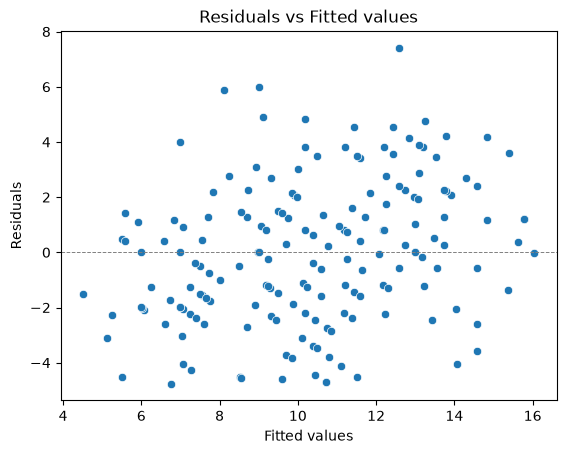

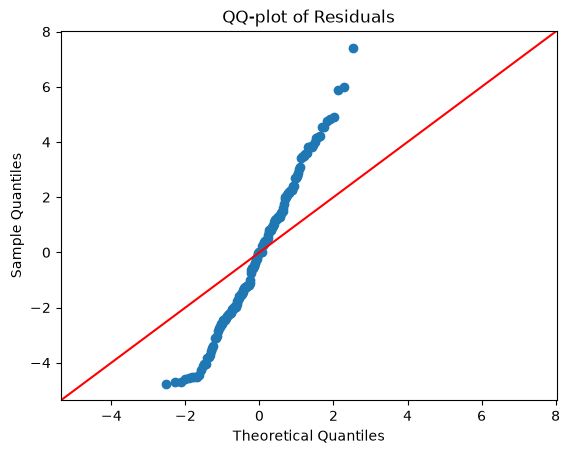


--- Wald Test (Global Effect by Term) ---
                 chi2        P>chi2  df constraint
Intercept  250.664691  1.860081e-56              1
session      9.854924  1.984046e-02              3

--- Wald Test (Global Effect: ALL Fixed Coefficients) ---
<Wald test (chi2): statistic=498.34807045034864, p-value=1.5252242505105728e-106, df_denom=4>

--- Wald Test (Global Effect: ALL Predictors, No Intercept) ---
<Wald test (chi2): statistic=9.854924066308836, p-value=0.019840455848566835, df_denom=3>

R-squared:
Marginal R-squared:    0.0282
Conditional R-squared: 0.5131

Per-term marginal R-squared:
Parameter Terms_removed  Full_marginal_R2  Reduced_marginal_R2  Delta_R2  Partial_R2            Type Status
  session       session          0.028772                  0.0  0.028772    0.028772 individual term     ok
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: tfeq_restrt
No. Observations: 176     Method:             REML       
No. Groups:   

C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:262: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  comparison_fit = comparison_model.fit(
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:299: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  reduced_fit = reduced_model.fit(
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:93: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  mixed_fit = mixed.fit(reml=reml, warn_convergence=False)


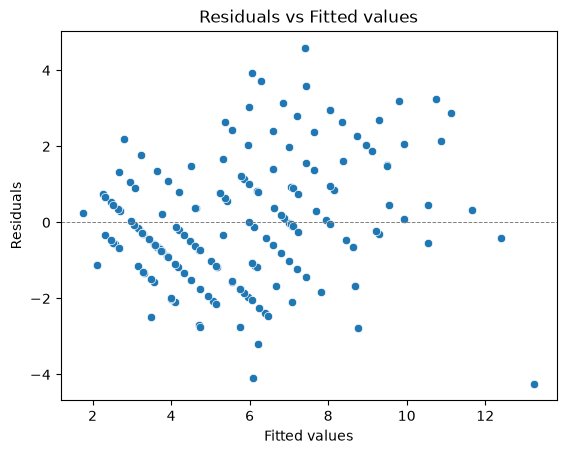

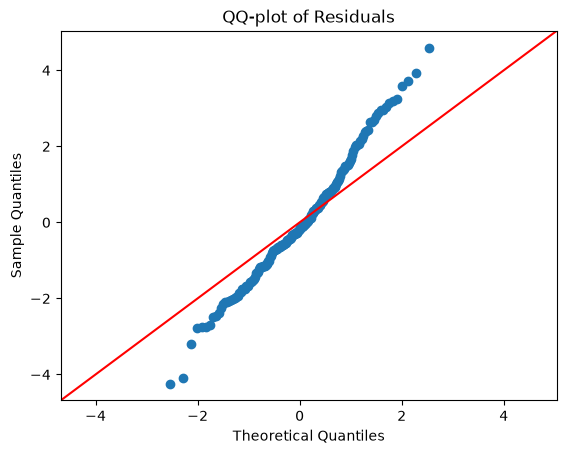


--- Wald Test (Global Effect by Term) ---
                 chi2        P>chi2  df constraint
Intercept  426.296851  1.039648e-94              1
session    103.322408  2.999200e-22              3

--- Wald Test (Global Effect: ALL Fixed Coefficients) ---
<Wald test (chi2): statistic=437.7652240804538, p-value=1.9172568309212664e-93, df_denom=4>

--- Wald Test (Global Effect: ALL Predictors, No Intercept) ---
<Wald test (chi2): statistic=103.32240777218281, p-value=2.9992001690180694e-22, df_denom=3>

R-squared:
Marginal R-squared:    0.2114
Conditional R-squared: 0.6464

Per-term marginal R-squared:
Parameter Terms_removed  Full_marginal_R2  Reduced_marginal_R2  Delta_R2  Partial_R2            Type Status
  session       session          0.214956                  0.0  0.214956    0.214956 individual term     ok
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: tfeq_dist
No. Observations: 177     Method:             REML     
No. Groups:       

C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:262: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  comparison_fit = comparison_model.fit(
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:299: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  reduced_fit = reduced_model.fit(
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:93: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  mixed_fit = mixed.fit(reml=reml, warn_convergence=False)


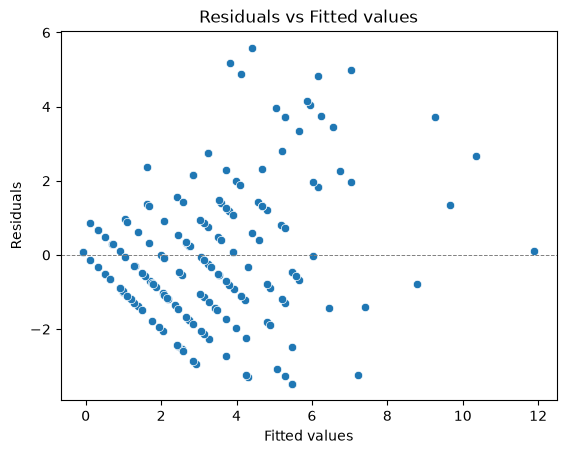

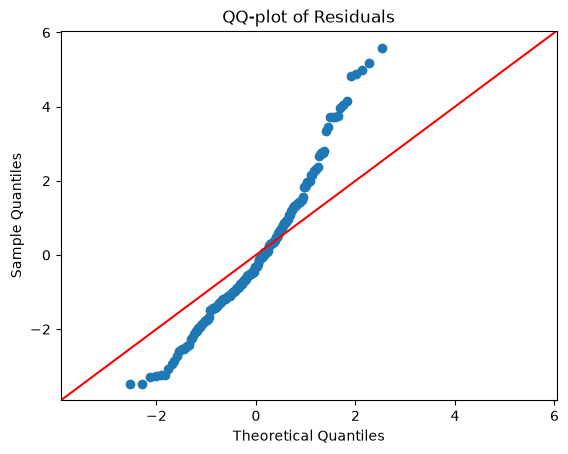


--- Wald Test (Global Effect by Term) ---
                 chi2        P>chi2  df constraint
Intercept  147.406972  6.393900e-34              1
session     40.753051  7.377296e-09              3

--- Wald Test (Global Effect: ALL Fixed Coefficients) ---
<Wald test (chi2): statistic=156.5756638434213, p-value=7.929268766410954e-33, df_denom=4>

--- Wald Test (Global Effect: ALL Predictors, No Intercept) ---
<Wald test (chi2): statistic=40.75305070356946, p-value=7.377295904402042e-09, df_denom=3>

R-squared:
Marginal R-squared:    0.1110
Conditional R-squared: 0.5270

Per-term marginal R-squared:
Parameter Terms_removed  Full_marginal_R2  Reduced_marginal_R2  Delta_R2  Partial_R2            Type Status
  session       session          0.113122                  0.0  0.113122    0.113122 individual term     ok
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: tfeq_hungert
No. Observations: 177     Method:             REML        
No. Groups:   

C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:262: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  comparison_fit = comparison_model.fit(
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:299: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  reduced_fit = reduced_model.fit(


In [12]:
# Print descriptive statistics for TFEQ components by session
print("=== TFEQ Restraint by Session ===")
print(df_hi_calories_final.groupby('session')['tfeq_restrt'].agg(['mean', 'std', 'count']))

print("\n=== TFEQ Disinhibition by Session ===")
print(df_hi_calories_final.groupby('session')['tfeq_dist'].agg(['mean', 'std', 'count']))

print("\n=== TFEQ Hunger by Session ===")
print(df_hi_calories_final.groupby('session')['tfeq_hungert'].agg(['mean', 'std', 'count']))

print("\n" + "="*50 + "\n")

# Fit LMM for TFEQ Restraint (TFEQ as outcome, session as predictor)
results_restraint_session_final, _ = fit_lmm(
    df=df_hi_calories_final,
    formula='tfeq_restrt ~ session',
    group_col='id_participant',
    session_summary_vars=['tfeq_restrt'],
    session_summary_col='session',
    print_session_summary=True,
    re_formula='1'
)



# Fit LMM for TFEQ Disinhibition (TFEQ as outcome, session as predictor)
results_disinhibition_session_final, _ = fit_lmm(
    df=df_hi_calories_final,
    formula='tfeq_dist ~ session',
    group_col='id_participant',
    session_summary_vars=['tfeq_dist'],
    session_summary_col='session',
    print_session_summary=True,
    re_formula='1'
)



# Fit LMM for TFEQ Hunger (TFEQ as outcome, session as predictor)
results_hunger_session_final, _ = fit_lmm(
    df=df_hi_calories_final,
    formula='tfeq_hungert ~ session',
    group_col='id_participant',
    session_summary_vars=['tfeq_hungert'],
    session_summary_col='session',
    print_session_summary=True,
    re_formula='1'
)



## Save dfs for TFEQ analysis in R (figure 2)

In [13]:
output_dir = "C:\\Users\\Patrick\\Gutbrain_R\\data"

df_hi_n_lo_final.to_csv(
    f"{output_dir}/df_hi_n_lo_final.tsv",
    sep="\t",
    index=False
)

df_hi_calories_final.to_csv(
    f"{output_dir}/df_hi_calories_final.tsv",
    sep="\t",
    index=False
)

print("Files saved successfully.")

Files saved successfully.


# Final basic stats (Table 1)

## compute averages and std + session + simple LMM for p values

DESCRIPTIVE STATISTICS BY SESSION

poids_bioimp_dance_x
               mean        std  count
session                              
1        121.194737  13.722615     57
2         93.992308  10.998963     52
3         78.752174  11.387825     46
4         79.013636  11.450715     44

--- LMM: poids_bioimp_dance_x ~ session ---
Dropped session / id_participant pairs and NaN source columns:
Empty DataFrame
Columns: [session, id_participant, nan_columns]
Index: []
Number of dropped pairs: 0


C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:93: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  mixed_fit = mixed.fit(reml=reml, warn_convergence=False)


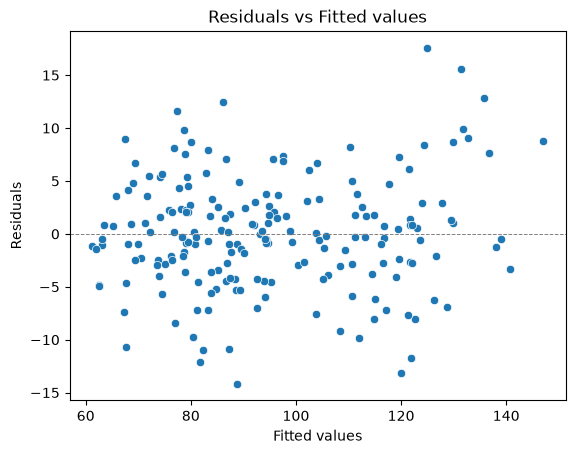

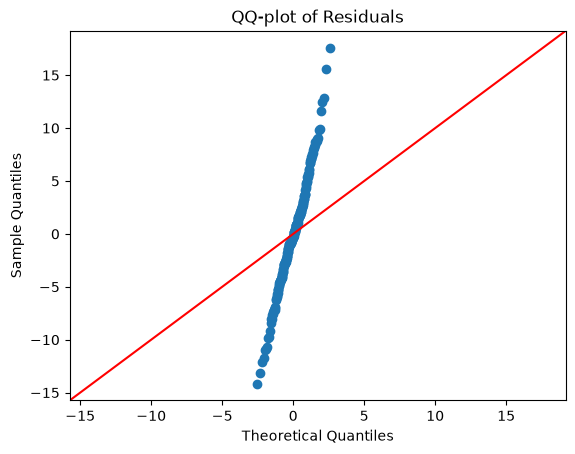


--- Wald Test (Global Effect by Term) ---
                  chi2  P>chi2  df constraint
Intercept  5954.039040     0.0              1
session    1600.480351     0.0              3

--- Wald Test (Global Effect: ALL Fixed Coefficients) ---
<Wald test (chi2): statistic=6163.137999745034, p-value=0.0, df_denom=4>

--- Wald Test (Global Effect: ALL Predictors, No Intercept) ---
<Wald test (chi2): statistic=1600.4803505306654, p-value=0.0, df_denom=3>


C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:262: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  comparison_fit = comparison_model.fit(
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:299: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  reduced_fit = reduced_model.fit(



R-squared:
Marginal R-squared:    0.6965
Conditional R-squared: 0.9161

Per-term marginal R-squared:
Parameter Terms_removed  Full_marginal_R2  Reduced_marginal_R2  Delta_R2  Partial_R2            Type Status
  session       session           0.70047                  0.0   0.70047     0.70047 individual term     ok
              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: poids_bioimp_dance_x
No. Observations: 199     Method:             REML                
No. Groups:       57      Scale:              38.8831             
Min. group size:  2       Log-Likelihood:     -705.6687           
Max. group size:  4       Converged:          Yes                 
Mean group size:  3.5                                             
-------------------------------------------------------------------
                 Coef.   Std.Err.     z     P>|z|   [0.025   0.975]
-------------------------------------------------------------------
Intercept       121.195 

C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:93: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  mixed_fit = mixed.fit(reml=reml, warn_convergence=False)


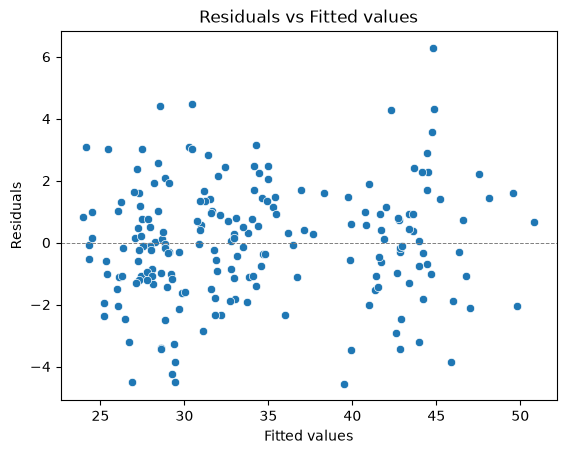

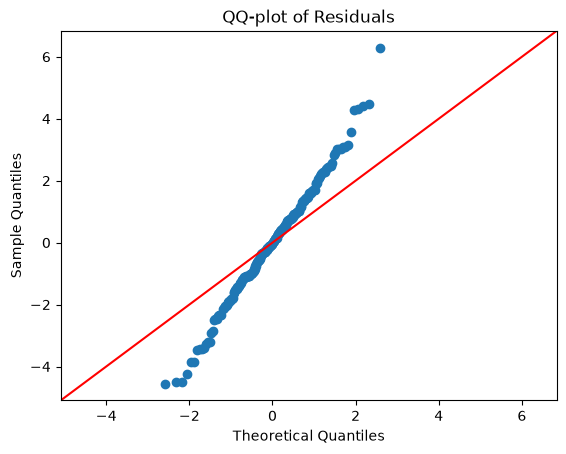


--- Wald Test (Global Effect by Term) ---
                  chi2  P>chi2  df constraint
Intercept  9304.898426     0.0              1
session    1740.654779     0.0              3

--- Wald Test (Global Effect: ALL Fixed Coefficients) ---
<Wald test (chi2): statistic=9712.84079733866, p-value=0.0, df_denom=4>

--- Wald Test (Global Effect: ALL Predictors, No Intercept) ---
<Wald test (chi2): statistic=1740.6547788210507, p-value=0.0, df_denom=3>

R-squared:
Marginal R-squared:    0.7815
Conditional R-squared: 0.9132

Per-term marginal R-squared:
Parameter Terms_removed  Full_marginal_R2  Reduced_marginal_R2  Delta_R2  Partial_R2            Type Status
  session       session          0.784768                  0.0  0.784768    0.784768 individual term     ok
           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: imc_recherche
No. Observations: 199     Method:             REML         
No. Groups:       57      Scale:              4.6658       
Mi

C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:262: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  comparison_fit = comparison_model.fit(
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:299: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  reduced_fit = reduced_model.fit(
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:93: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  mixed_fit = mixed.fit(reml=reml, warn_convergence=False)


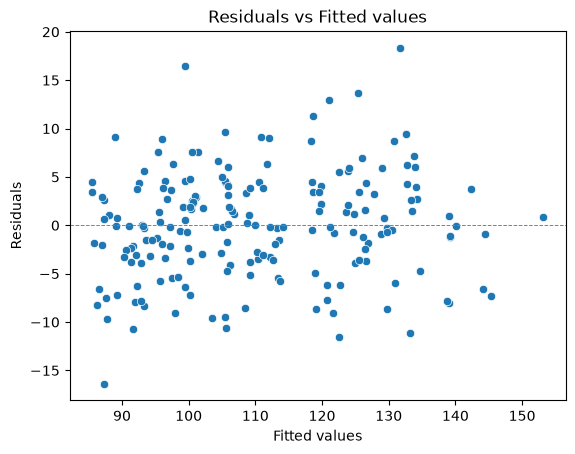

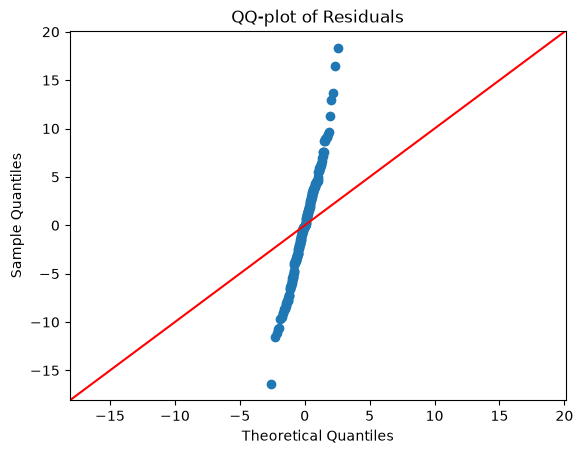


--- Wald Test (Global Effect by Term) ---
                  chi2         P>chi2  df constraint
Intercept  8995.249014   0.000000e+00              1
session     937.531182  6.398615e-203              3

--- Wald Test (Global Effect: ALL Fixed Coefficients) ---
<Wald test (chi2): statistic=9687.880566318288, p-value=0.0, df_denom=4>

--- Wald Test (Global Effect: ALL Predictors, No Intercept) ---
<Wald test (chi2): statistic=937.5311817278815, p-value=6.398615251337215e-203, df_denom=3>

R-squared:
Marginal R-squared:    0.6466
Conditional R-squared: 0.8669

Per-term marginal R-squared:
Parameter Terms_removed  Full_marginal_R2  Reduced_marginal_R2  Delta_R2  Partial_R2            Type Status
  session       session           0.65092                  0.0   0.65092     0.65092 individual term     ok
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: bi_ttaille_scan
No. Observations: 199     Method:             REML           
No. Groups:      

C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:262: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  comparison_fit = comparison_model.fit(
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:299: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  reduced_fit = reduced_model.fit(
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:93: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  mixed_fit = mixed.fit(reml=reml, warn_convergence=False)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:93: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  mixed_fit = mixed.fit(reml=reml, warn_convergence=False)


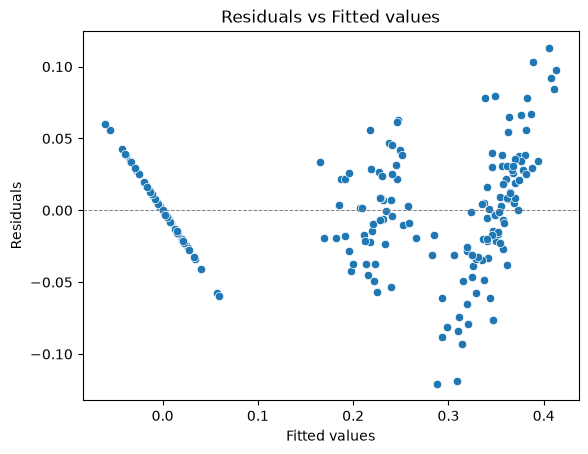

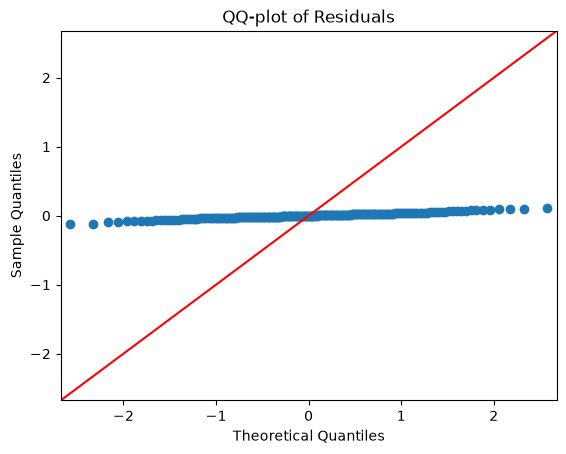


--- Wald Test (Global Effect by Term) ---
                   chi2  P>chi2  df constraint
Intercept  2.584072e-28     1.0              1
session    2.212537e+03     0.0              3

--- Wald Test (Global Effect: ALL Fixed Coefficients) ---
<Wald test (chi2): statistic=3889.354648846316, p-value=0.0, df_denom=4>

--- Wald Test (Global Effect: ALL Predictors, No Intercept) ---
<Wald test (chi2): statistic=2212.537196053119, p-value=0.0, df_denom=3>

R-squared:
Marginal R-squared:    0.8816
Conditional R-squared: 0.9223

Per-term marginal R-squared:
Parameter Terms_removed  Full_marginal_R2  Reduced_marginal_R2  Delta_R2  Partial_R2            Type Status
  session       session          0.883647                  0.0  0.883647    0.883647 individual term     ok
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: twl_recherche_x
No. Observations: 199     Method:             REML           
No. Groups:       57      Scale:              0.0019  

C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:262: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  comparison_fit = comparison_model.fit(
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:262: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  comparison_fit = comparison_model.fit(
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:299: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  reduced_fit = reduced_model.fit(
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:93: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  mixed_fit = mixed.fit(reml=reml, warn_convergence=False)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:93: ConvergenceWarning: The MLE may be on the boundary of the para

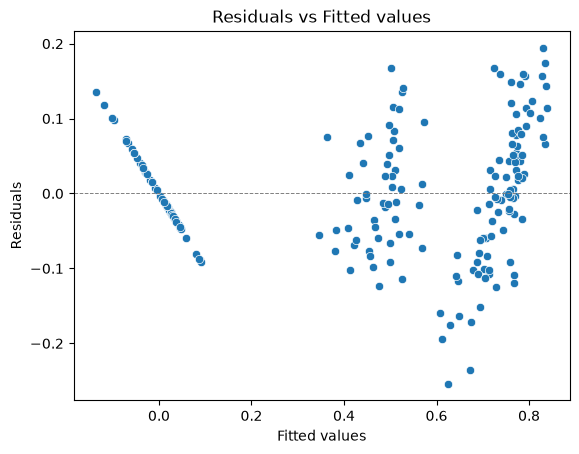

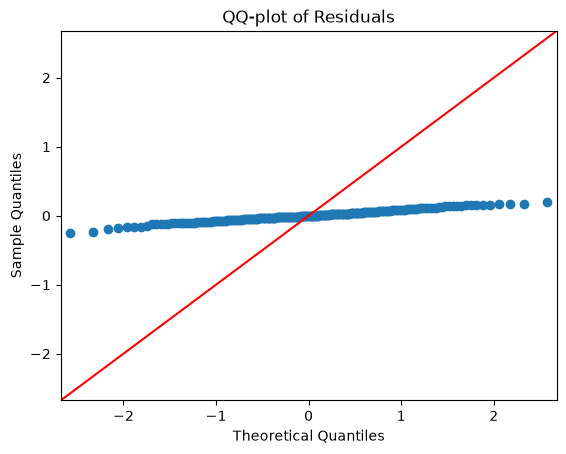


--- Wald Test (Global Effect by Term) ---
                   chi2  P>chi2  df constraint
Intercept  1.125552e-29     1.0              1
session    2.299805e+03     0.0              3

--- Wald Test (Global Effect: ALL Fixed Coefficients) ---
<Wald test (chi2): statistic=4104.08550120257, p-value=0.0, df_denom=4>

--- Wald Test (Global Effect: ALL Predictors, No Intercept) ---
<Wald test (chi2): statistic=2299.805470300188, p-value=0.0, df_denom=3>

R-squared:
Marginal R-squared:    0.8872
Conditional R-squared: 0.9247

Per-term marginal R-squared:
Parameter Terms_removed  Full_marginal_R2  Reduced_marginal_R2  Delta_R2  Partial_R2            Type Status
  session       session          0.889161                  0.0  0.889161    0.889161 individual term     ok
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: ewl_recherche_x
No. Observations: 199     Method:             REML           
No. Groups:       57      Scale:              0.0083   

C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:262: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  comparison_fit = comparison_model.fit(
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:262: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  comparison_fit = comparison_model.fit(
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:299: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  reduced_fit = reduced_model.fit(
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:93: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  mixed_fit = mixed.fit(reml=reml, warn_convergence=False)


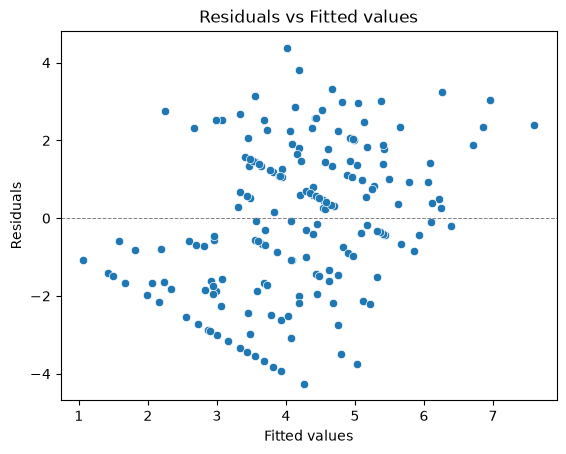

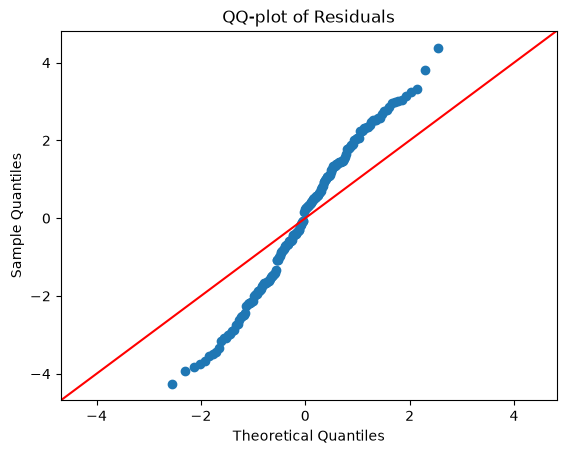


--- Wald Test (Global Effect by Term) ---
                 chi2        P>chi2  df constraint
Intercept  158.023779  3.058054e-36              1
session     11.161048  1.088615e-02              3

--- Wald Test (Global Effect: ALL Fixed Coefficients) ---
<Wald test (chi2): statistic=317.8079871014418, p-value=1.5585895453864505e-67, df_denom=4>

--- Wald Test (Global Effect: ALL Predictors, No Intercept) ---
<Wald test (chi2): statistic=11.161048364813603, p-value=0.010886151745805445, df_denom=3>

R-squared:
Marginal R-squared:    0.0428
Conditional R-squared: 0.3159

Per-term marginal R-squared:
Parameter Terms_removed  Full_marginal_R2  Reduced_marginal_R2  Delta_R2  Partial_R2            Type Status
  session       session          0.043735                  0.0  0.043735    0.043735 individual term     ok
             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: vas_hunger_before
No. Observations: 184     Method:             REML             


C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:262: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  comparison_fit = comparison_model.fit(
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:299: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  reduced_fit = reduced_model.fit(


                 chi2        P>chi2  df constraint
Intercept  158.023779  3.058054e-36              1
session     11.161048  1.088615e-02              3

vas_hunger_after
             mean       std  count
session                           
1        6.656863  2.220924     51
2        6.336957  2.354793     46
3        7.300000  2.096664     36
4        6.866667  1.623241     39

--- LMM: vas_hunger_after ~ session ---
Dropped session / id_participant pairs and NaN source columns:
   session id_participant       nan_columns
0        1         rcx097  vas_hunger_after
1        1         rcx136  vas_hunger_after
2        1         rnd027  vas_hunger_after
3        1         rnd034  vas_hunger_after
4        1         rnd037  vas_hunger_after
5        1         rnd041  vas_hunger_after
6        2         rcx097  vas_hunger_after
7        2         rcx136  vas_hunger_after
8        2         rnd023  vas_hunger_after
9        2         rnd025  vas_hunger_after
10       2         rnd027  vas_

C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:93: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  mixed_fit = mixed.fit(reml=reml, warn_convergence=False)


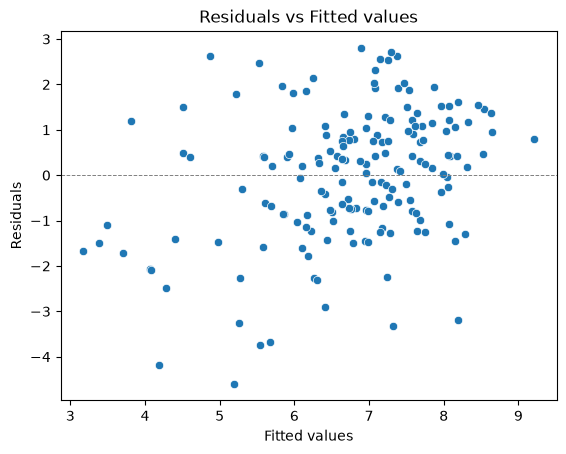

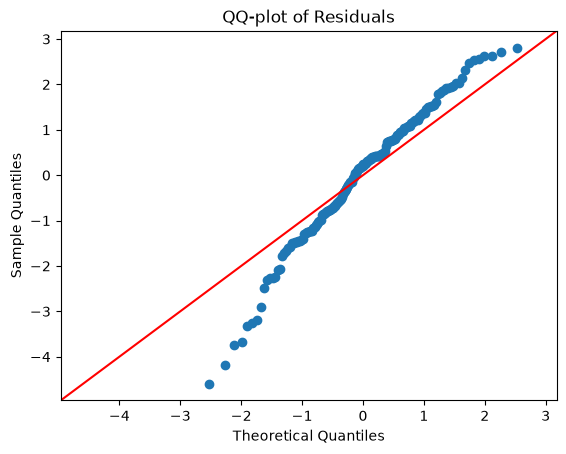


--- Wald Test (Global Effect by Term) ---
                 chi2         P>chi2  df constraint
Intercept  519.146012  6.491403e-115              1
session      5.671684   1.287231e-01              3

--- Wald Test (Global Effect: ALL Fixed Coefficients) ---
<Wald test (chi2): statistic=930.6544091805397, p-value=3.7988620146070086e-200, df_denom=4>

--- Wald Test (Global Effect: ALL Predictors, No Intercept) ---
<Wald test (chi2): statistic=5.6716836061138665, p-value=0.1287231225754433, df_denom=3>


C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:262: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  comparison_fit = comparison_model.fit(
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:299: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  reduced_fit = reduced_model.fit(



R-squared:
Marginal R-squared:    0.0208
Conditional R-squared: 0.4113

Per-term marginal R-squared:
Parameter Terms_removed  Full_marginal_R2  Reduced_marginal_R2  Delta_R2  Partial_R2            Type Status
  session       session          0.021291                  0.0  0.021291    0.021291 individual term     ok
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: vas_hunger_after
No. Observations: 172     Method:             REML            
No. Groups:       54      Scale:              2.6784          
Min. group size:  1       Log-Likelihood:     -358.2364       
Max. group size:  4       Converged:          Yes             
Mean group size:  3.2                                         
---------------------------------------------------------------
                Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------------
Intercept        6.695     0.294  22.785  0.000   6.119   7.27

In [14]:
# List of variables to analyze
variables = [
    'poids_bioimp_dance_x',
    'imc_recherche',
    'bi_ttaille_scan',
    'twl_recherche_x',
    'ewl_recherche_x',
    'vas_hunger_before',
    'vas_hunger_after'
]

print("=" * 80)
print("DESCRIPTIVE STATISTICS BY SESSION")
print("=" * 80)

for var in variables:
    print(f"\n{'='*80}")
    print(f"{var}")
    print(f"{'='*80}")
    
    if var in df_hi_calories_final.columns:
        stats_df = df_hi_calories_final.groupby('session')[var].agg(['mean', 'std', 'count'])
        print(stats_df)
        
        # Fit LMM
        print(f"\n--- LMM: {var} ~ session ---")
        try:
            result, diagnostics = fit_lmm(
                df=df_hi_calories_final,
                formula=f'{var} ~ session',
                group_col='id_participant',
                re_formula='1'
            )
            
            # Add Wald test for session
            print(f"\n--- Wald Test (Global Session Effect) ---")
            wald_result = result.wald_test_terms(skip_single=False, scalar=True)
            print(wald_result)
            
        except Exception as e:
            print(f"Error fitting LMM: {e}")
    else:
        print(f"Variable '{var}' not found in dataframe")

## load remission data

In [15]:
file_path = r"C:\Users\Patrick\Gutbrain_R\data\RemissionCommun-PVSignesVitauxGutBra_DATA_LABELS_2026-02-09_1732.csv"
df_remission = pd.read_csv(file_path, sep="\t")

print(f"Dataset Shape: {df_remission.shape[0]} rows × {df_remission.shape[1]} columns")

for col in df_remission.columns:
    s = df_remission[col]
    print(f"\n{col}: {s.dtype} | non-null={s.notna().sum()} | null={s.isna().sum()} | unique={s.nunique()}")
    if pd.api.types.is_numeric_dtype(s):
        vals = s.dropna()
        if len(vals):
            print(vals.describe())
    else:
        print(s.dropna().unique()[:5])

summary_df = pd.DataFrame({
    "Column": df_remission.columns,
    "Type": df_remission.dtypes,
    "Non_Null": df_remission.notna().sum(),
    "Null": df_remission.isna().sum(),
    "Unique": df_remission.nunique()
})
print(summary_df)

Dataset Shape: 1441 rows × 67 columns

ID recherche: str | non-null=1276 | null=165 | unique=398
<StringArray>
['RCX001', 'RCX002', 'RCX003', 'RCX004', 'RCX005']
Length: 5, dtype: str

ID recherche.1: float64 | non-null=0 | null=1441 | unique=0

Record ID: int64 | non-null=1441 | null=0 | unique=406
count    1441.000000
mean      290.200555
std       212.572692
min         1.000000
25%        99.000000
50%       198.000000
75%       489.000000
max       659.000000
Name: Record ID, dtype: float64

Event Name: str | non-null=1441 | null=0 | unique=11
<StringArray>
['Consultation préop (Arm 1: RCX)',       'Suivi 4 mois (Arm 1: RCX)',
      'Suivi 12 mois (Arm 1: RCX)',      'Suivi 24 mois (Arm 1: RCX)',
 'Consultation préop (Arm 3: RND)']
Length: 5, dtype: str

Repeat Instrument: float64 | non-null=0 | null=1441 | unique=0

Repeat Instance: float64 | non-null=0 | null=1441 | unique=0

Date: str | non-null=1400 | null=41 | unique=959
<StringArray>
['2015-03-24', '2015-12-21', '2016-08-30'

## prepare remission df for merge

In [16]:
df_remission_prepared = df_remission.rename(columns={"ID recherche": "id_participant", "Event Name": "session"})
df_remission_prepared["id_participant"] = df_remission_prepared["id_participant"].astype(str).str.lower().str.strip()

def map_event_to_session(event_name):
    if pd.isna(event_name):
        return None
    e = str(event_name).lower()
    mapping = {
        "consultation": "1",
        "préop": "1",
        "suivi 4": "2",
        "suivi 12": "3",
        "suivi 24": "4",
    }
    for key, val in mapping.items():
        if key in e:
            return val
    return None

df_remission_prepared["session"] = df_remission_prepared["session"].apply(map_event_to_session)

df_remission_prepared["combo"] = df_remission_prepared["id_participant"] + "_" + df_remission_prepared["session"].astype(str)
df_hi_calories_final["combo"] = df_hi_calories_final["id_participant"] + "_" + df_hi_calories_final["session"].astype(str)

print(f"Matches: {len(set(df_remission_prepared['combo']) & set(df_hi_calories_final['combo']))}")

Matches: 197


## merge remission and final DF

In [17]:
df_merged_remission_final = df_hi_calories_final.merge(
    df_remission_prepared, 
    on=['id_participant', 'session'], 
    how='left'
)
df_merged_remission_final

,id_participant,session,redcap_event_name,Commentaires,Donnees utilisee pour CMDO,sexe,sexeF,t2d,type_chx,tx_t2d___1,...,Hémoglobine glyquée,Insuline,Date prélèvement c-peptide,c-peptide,Insuline du PV cpep,Glycémie à jeun du prélèvement c-peptide,Hémoglobine glyquée du prélèvement p-peptide,Note prélèvement,Complete?,combo_y
0,rcx097,1,baseline_arm_1,NaN,1.0,2.0,1.0,1.0,3.0,0.0,...,0.078,197.0,2016-06-28,1278.0,197.0,11.5,0.078,NaN,Complete,rcx097_1
1,rcx097,2,4_mois_arm_1,NaN,1.0,2.0,1.0,NaN,3.0,NaN,...,0.061,33.0,2017-05-03,602.0,33.0,4.7,0.061,NaN,Complete,rcx097_2
2,rcx097,3,12_mois_arm_1,NaN,1.0,2.0,1.0,NaN,3.0,NaN,...,0.054,17.0,2018-01-08,302.0,17.0,4.3,0.054,NaN,Complete,rcx097_3
3,rcx097,4,24_mois_arm_1,NaN,1.0,2.0,1.0,NaN,3.0,NaN,...,0.048,45.0,2019-01-22,392.0,45.0,5.3,0.048,NaN,Complete,rcx097_4
4,rcx126,1,baseline_arm_1,NaN,1.0,2.0,1.0,1.0,1.0,0.0,...,0.065,133.0,2016-12-01,1448.0,133.0,6.4,0.065,NaN,Complete,rcx126_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,rnd074,3,12_mois_arm_1,NaN,1.0,2.0,1.0,NaN,2.0,NaN,...,0.054,19.0,NaN,NaN,NaN,NaN,NaN,Pas de C-peptide,Unverified,rnd074_3
195,rnd074,4,24_mois_arm_1,jai le disque. disque sur l'ordi a justine. no...,1.0,2.0,1.0,NaN,2.0,NaN,...,0.054,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unverified,rnd074_4
196,rnd076,1,baseline_arm_1,NaN,1.0,1.0,0.0,2.0,1.0,0.0,...,0.058,439.0,2021-08-13,2049.0,439.0,6.0,NaN,NaN,Unverified,rnd076_1
197,rnd076,2,4_mois_arm_1,NaN,1.0,1.0,0.0,NaN,1.0,NaN,...,0.053,75.0,2022-09-06,609.0,75.0,5.7,NaN,NaN,Unverified,rnd076_2


## physiological stats table 1

In [18]:
# Apply data cleaning for known outliers
print("=" * 100)
print("DATA CLEANING: OUTLIER EXCLUSION AND CORRECTION")
print("=" * 100)

df_clean = df_merged_remission_final.copy()

# Exclude outlier
df_clean = df_clean[~(
    (df_clean["id_participant"] == "rnd074") &
    (df_clean["session"] == "3") &
    (df_clean["Glucose jeun"] == 43.8)
)]

# Correct typo
df_clean.loc[
    (df_clean["id_participant"] == "rnd067") &
    (df_clean["session"] == "1") &
    (df_clean["Cholestérol HDL"] == 10.3),
    "Cholestérol HDL"
] = 1.03

print("Data cleaning complete")
print(f"Rows retained: {len(df_clean)}")

# Clinical variables to summarize
variables = [
    "Tension artérielle systolique",
    "Tension artérielle diastolique",
    "PCO2",
    "Cholestérol total",
    "Triglycérides",
    "Cholestérol HDL",
    "Cholestérol LDL",
    "Cholestérol total/cholestérol HDL",
    "Apo-B",
    "Glucose jeun",
    "Hémoglobine glyquée",
    "Insuline"
]

# Summary stats by session
summary_results = []
for var in variables:
    stats = df_clean.groupby("session")[var].agg(["mean", "std", "count"])
    for s in stats.index:
        summary_results.append({
            "Variable": var,
            "Session": s,
            "Mean": stats.loc[s, "mean"],
            "Std": stats.loc[s, "std"],
            "N": stats.loc[s, "count"]
        })

summary_table = pd.DataFrame(summary_results).pivot(
    index="Variable",
    columns="Session",
    values=["Mean", "Std", "N"]
)

print("\n" + "=" * 100)
print("SUMMARY TABLE")
print("=" * 100)
print(summary_table)

# LMM models
lmm_results = {}
for var in variables:
    model_df = df_clean[["id_participant", "session", var]].copy()
    model_df = model_df.rename(columns={var: "outcome_var"})
    model_df["session"] = model_df["session"].astype(str)

    try:
        results, _ = fit_lmm(
            df=model_df,
            formula="outcome_var ~ C(session)",
            group_col="id_participant",
            re_formula="1",
            reml=True,
            plot=False,
            verbose=False,
            dropna=True
        )
        lmm_results[var] = results
    except Exception as e:
        print(f"Error fitting model for {var}: {e}")
        lmm_results[var] = None

# LMM summary
lmm_summary = []
for var, result in lmm_results.items():
    if result is None:
        continue

    params = result.params
    pvals = result.pvalues
    ci = result.conf_int()

    for param in [p for p in params.index if "session" in p]:
        lmm_summary.append({
            "Variable": var,
            "Parameter": param,
            "Coefficient": params[param],
            "p_value": pvals[param],
            "CI_lower": ci.loc[param, 0],
            "CI_upper": ci.loc[param, 1],
            "Significant": pvals[param] < 0.05
        })

lmm_summary_df = pd.DataFrame(lmm_summary)

print("\n" + "=" * 100)
print("SUMMARY OF LMM RESULTS")
print("=" * 100)
print(lmm_summary_df.to_string(index=False))

DATA CLEANING: OUTLIER EXCLUSION AND CORRECTION
Data cleaning complete
Rows retained: 198

SUMMARY TABLE
                                         Mean                          \
Session                                     1           2           3   
Variable                                                                
Apo-B                                0.951429    0.779737    0.760000   
Cholestérol HDL                      1.192143    1.130250    1.427209   
Cholestérol LDL                      2.590714    2.054750    2.194419   
Cholestérol total                    4.536607    3.790000    4.115814   
Cholestérol total/cholestérol HDL    3.955714    3.443500    2.968605   
Glucose jeun                         6.001786    5.040476    4.716279   
Hémoglobine glyquée                  0.056589    0.052255    0.051070   
Insuline                           174.071429   64.491429   43.575758   
PCO2                                38.989091  145.000000         NaN   
Tension artérielle 

C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:93: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  mixed_fit = mixed.fit(reml=reml, warn_convergence=False)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:262: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  comparison_fit = comparison_model.fit(


C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:299: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  reduced_fit = reduced_model.fit(


Dropped session / id_participant pairs and NaN source columns:
  session id_participant  nan_columns
0       1         rcx219  outcome_var
1       1         rnd030  outcome_var
2       2         rnd047  outcome_var
Number of dropped pairs: 3


C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:93: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  mixed_fit = mixed.fit(reml=reml, warn_convergence=False)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:262: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  comparison_fit = comparison_model.fit(
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:299: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  reduced_fit = reduced_model.fit(


...

C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:93: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  mixed_fit = mixed.fit(reml=reml, warn_convergence=False)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:262: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  comparison_fit = comparison_model.fit(
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:299: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  reduced_fit = reduced_model.fit(


Dropped session / id_participant pairs and NaN source columns:
  session id_participant  nan_columns
0       1         rcx219  outcome_var
1       2         rnd047  outcome_var
2       3         rnd023  outcome_var
3       3         rnd061  outcome_var
4       4         rnd023  outcome_var
Number of dropped pairs: 5


C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:93: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  mixed_fit = mixed.fit(reml=reml, warn_convergence=False)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:93: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  mixed_fit = mixed.fit(reml=reml, warn_convergence=False)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:262: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  comparison_fit = comparison_model.fit(
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:262: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  comparison_fit = comparison_model.fit(
C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:299: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future ver

Dropped session / id_participant pairs and NaN source columns:
   session id_participant  nan_columns
0        1         rcx219  outcome_var
1        2         rnd003  outcome_var
2        2         rnd004  outcome_var
3        2         rnd007  outcome_var
4        2         rnd009  outcome_var
5        2         rnd011  outcome_var
6        2         rnd013  outcome_var
7        2         rnd015  outcome_var
8        2         rnd016  outcome_var
9        2         rnd018  outcome_var
10       2         rnd020  outcome_var
11       2         rnd021  outcome_var
12       2         rnd022  outcome_var
13       2         rnd025  outcome_var
14       2         rnd041  outcome_var
15       2         rnd047  outcome_var
16       2         rnd059  outcome_var
17       2         rnd069  outcome_var
18       3         rnd003  outcome_var
19       3         rnd004  outcome_var
20       3         rnd009  outcome_var
21       3         rnd014  outcome_var
22       3         rnd018  outcome_var
2

C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:299: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  reduced_fit = reduced_model.fit(


## Updated HOMA-IR withouth glucose a jeun outlier

In [19]:
# HOMA-IR calculation using df_clean
df_clean = df_clean[df_clean["Insuline"].notna() & df_clean["Glucose jeun"].notna()].copy()

df_clean["Insuline_mU_L"] = df_clean["Insuline"] / 6.00
df_clean["HOMA_IR"] = (df_clean["Insuline_mU_L"] * df_clean["Glucose jeun"]) / 22.5

print(f"Rows after filtering: {len(df_clean)}")
print(f"HOMA-IR values computed: {df_clean['HOMA_IR'].notna().sum()}")

print("\nHOMA-IR summary by session:")
print(df_clean.groupby("session")["HOMA_IR"].agg(["mean", "std", "count"]))

# Fit HOMA-IR LMM
model_df = df_clean[["id_participant", "session", "HOMA_IR"]].copy()
model_df = model_df.rename(columns={"HOMA_IR": "outcome_var"})
model_df["session"] = model_df["session"].astype(str)

try:
    results, _ = fit_lmm(
        df=model_df,
        formula="outcome_var ~ C(session)",
        group_col="id_participant",
        re_formula="1",
        reml=True,
        plot=False,
        verbose=False,
        dropna=True
    )

    print("\nCoefficients for HOMA-IR:")
    print(results.summary().tables[1])

    print("\nWald test for session effect:")
    print(results.wald_test_terms(skip_single=False, scalar=True))
except Exception as e:
    print(f"Error fitting model for HOMA-IR: {e}")

C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:93: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  mixed_fit = mixed.fit(reml=reml, warn_convergence=False)


Rows after filtering: 158
HOMA-IR values computed: 158

HOMA-IR summary by session:
             mean       std  count
session                           
1        8.172407  6.764611     56
2        2.550129  1.947441     35
3        1.594747  1.187618     33
4        1.732056  0.918388     34
Dropped session / id_participant pairs and NaN source columns:
Empty DataFrame
Columns: [session, id_participant, nan_columns]
Index: []
Number of dropped pairs: 0


C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:262: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  comparison_fit = comparison_model.fit(



Coefficients for HOMA-IR:
                  Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept         8.170    0.564  14.498  0.000   7.066   9.275
C(session)[T.2]  -5.837    0.843  -6.926  0.000  -7.489  -4.185
C(session)[T.3]  -6.682    0.855  -7.814  0.000  -8.358  -5.006
C(session)[T.4]  -6.484    0.844  -7.685  0.000  -8.138  -4.831
Group Var         3.298    0.599                               

Wald test for session effect:
                  chi2        P>chi2  df constraint
Intercept   210.204489  1.239516e-47              1
C(session)   97.020365  6.793226e-21              3


C:\Users\Patrick\AppData\Local\Temp\ipykernel_24016\153212968.py:299: FutureWarning: Argument warn_convergence not used by MixedLM.fit. Future versions will raise on these arguments.
  reduced_fit = reduced_model.fit(


## remision final commun to tsv

In [20]:
# Save df_merged_remission_final to TSV file
output_path = 'C:\\Users\\Patrick\\Gutbrain_R\\data\\df_merged_remission_final.tsv'

df_merged_remission_final.to_csv(output_path, sep='\t', index=False)

print(f"Successfully saved df_merged_remission_final to: {output_path}")
print(f"Shape: {df_merged_remission_final.shape}")
print(f"Columns: {len(df_merged_remission_final.columns)}")

Successfully saved df_merged_remission_final to: C:\Users\Patrick\Gutbrain_R\data\df_merged_remission_final.tsv
Shape: (199, 356)
Columns: 356


# Supplementary figures with final sample

## Food comparisons

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FormatStrFormatter, FixedLocator
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')



print(f"df_final shape: {df_final.shape}")

# Create valid combinations - convert sess to string to match df session format
valid_combinations = set(
    df_final[['Subj', 'sess']].apply(lambda row: (row['Subj'].lower(), str(row['sess'])), axis=1)
)

print(f"Number of valid (participant, session) combinations in df_final: {len(valid_combinations)}")
print(f"Sample valid combinations: {list(valid_combinations)[:5]}")

# Define significance symbols per test type
test_symbols = {
    't-test': '*',           # Asterisk for t-test
    "Welch's t": '†',        # Dagger for Welch's t-test
    'Mann-Whitney': '‡'      # Double dagger for Mann-Whitney
}

# Define nice labels for each property
property_labels = {
    'prix_gramme': 'Retail Price per Gram ($/g)',
    'like': 'Pre-surgery Liking Rating',
    'kcalreal_y': 'True Caloric Density (kcal/g)',
    'brightness': 'Brightness',
    'mean_color_b': 'Blue Channel',
    'mean_color_g': 'Green Channel',
    'mean_color_r': 'Red Channel',
    'Prix': 'Retail Price ($)',
    'estcal': 'Estimated Caloric Density',
    'contrast': 'Contrast',
    'num_object_pixels': 'Object Size (kpixels)',
    'calories_shown': 'Calories Shown (kcal)',
    'response_time': 'Response Time (s)',
    'Grammes montrés (Selon l\'image)': 'Mass Shown (g)'
}

# Define fixed y-axis limits for specific properties
y_axis_limits = {
    'mean_color_r': (0, 255),
    'mean_color_g': (0, 255),
    'mean_color_b': (0, 255),
    'estcal': (0, 5),
    'like': (0, 5),
    'kcalreal_y': (0, 7),
    'num_object_pixels': (30, 120)
}

# Define y-axis ticks for specific properties
y_axis_ticks = {
    'mean_color_r': [0, 50, 100, 150, 200, 255],
    'mean_color_g': [0, 50, 100, 150, 200, 255],
    'mean_color_b': [0, 50, 100, 150, 200, 255],
    'estcal': [0, 1, 2, 3, 4, 5],
    'like': [0, 1, 2, 3, 4, 5],
    'num_object_pixels': [30, 40, 50, 60, 70, 80, 90, 100, 110, 120]
}

# Filter data: FIRST filter to valid combinations from df_final
print(f"\nBefore filtering to df_final combinations: {len(df)} rows")

# Ensure session is string for comparison
df_filtered = df.copy()
df_filtered['session'] = df_filtered['session'].astype(str)

# Filter to only valid (participant, session) combinations from df_final
df_filtered = df_filtered[
    df_filtered.apply(lambda row: (row['id_participant'].lower(), str(row['session'])) in valid_combinations, axis=1)
]

print(f"After filtering to df_final combinations: {len(df_filtered)} rows")

# Keep only sessions 1-4 (should already be satisfied by df_final, but just to be sure)
df_filtered = df_filtered[df_filtered['session'].isin(['1', '2', '3', '4'])]

print(f"After filtering to sessions 1-4: {len(df_filtered)} rows")
print(f"Unique participants: {df_filtered['id_participant'].nunique()}")
print(f"Unique sessions: {sorted(df_filtered['session'].unique())}")

# Convert num_object_pixels to kpixels (divide by 1000)
df_filtered['num_object_pixels'] = df_filtered['num_object_pixels'] / 1000

# Aggregate by picture (mean across all participants and sessions)
print("\nAggregating data by picture...")
all_properties = ['mean_color_r', 'mean_color_g', 'mean_color_b', 'brightness', 'contrast', 
                 'num_object_pixels','kcalreal_y', 'estcal', 'calories_shown', 
                 'response_time', 'like','prix_gramme', 'Prix', 'Grammes montrés (Selon l\'image)']

agg_dict = {}
for prop in all_properties:
    agg_dict[prop] = 'mean'
agg_dict['calories'] = 'first'

df_agg = df_filtered.groupby('picture', as_index=False).agg(agg_dict)

print(f"Filtered data (valid combinations only): {len(df_filtered)} rows")
print(f"Aggregated data: {len(df_agg)} rows (unique pictures)")
print(f"Calories distribution: {df_agg['calories'].value_counts().to_dict()}")

# Function to perform normality test
def test_normality(data):
    """Shapiro-Wilk test for normality. Returns p-value."""
    if len(data) < 3 or len(data) > 5000:
        return np.nan
    try:
        _, p = shapiro(data)
        return p
    except:
        return np.nan

# Function to perform equality of variances test
def test_equal_variances(data1, data2):
    """Levene's test for equality of variances. Returns p-value."""
    if len(data1) < 2 or len(data2) < 2:
        return np.nan
    try:
        _, p = levene(data1, data2)
        return p
    except:
        return np.nan

# Function to compute Cohen's d (pooled SD effect size)
def cohens_d(data_hi, data_lo):
    """Compute Cohen's d for High vs Low calorie groups using pooled SD."""
    if len(data_hi) < 2 or len(data_lo) < 2:
        return np.nan
    
    hi_mean = np.mean(data_hi)
    lo_mean = np.mean(data_lo)
    hi_sd = np.std(data_hi, ddof=1)
    lo_sd = np.std(data_lo, ddof=1)
    
    pooled_sd = np.sqrt(
        (((len(data_hi) - 1) * hi_sd**2) + ((len(data_lo) - 1) * lo_sd**2)) /
        (len(data_hi) + len(data_lo) - 2)
    )
    
    if np.isclose(pooled_sd, 0):
        return 0.0
    
    return (hi_mean - lo_mean) / pooled_sd

def perform_statistical_test(data_hi, data_lo):
    """
    Determine appropriate test based on normality and variance equality.
    Returns: (test_name, statistic, p_value, p_norm_hi, p_norm_lo, p_var, d)
    """
    p_norm_hi = test_normality(data_hi)
    p_norm_lo = test_normality(data_lo)
    d = cohens_d(data_hi, data_lo)
    
    print(f"  Normality test - High: p={p_norm_hi:.4f}, Low: p={p_norm_lo:.4f}")
    print(f"  Cohen's d = {d:.3f}")
    
    both_normal = not np.isnan(p_norm_hi) and not np.isnan(p_norm_lo) and (p_norm_hi > 0.05) and (p_norm_lo > 0.05)
    
    if both_normal:
        p_var = test_equal_variances(data_hi, data_lo)
        print(f"  Equal variance test: p={p_var:.4f}")
        
        if p_var > 0.05:
            stat, p = ttest_ind(data_hi, data_lo, equal_var=True)
            return ('t-test', stat, p, p_norm_hi, p_norm_lo, p_var, d)
        else:
            stat, p = ttest_ind(data_hi, data_lo, equal_var=False)
            return ("Welch's t", stat, p, p_norm_hi, p_norm_lo, p_var, d)
    else:
        stat, p = mannwhitneyu(data_hi, data_lo, alternative='two-sided')
        return ('Mann-Whitney', stat, p, p_norm_hi, p_norm_lo, np.nan, d)

# Colors for box plots
colors = {'hi': 'orange', 'lo': 'blue'}

# Store all statistical results
all_stats_results = []

def create_figure(properties_rows, figure_title):
    """Create a figure with multiple rows of properties"""
    global all_stats_results
    
    panel_counter = 0
    
    for row_idx, row_properties in enumerate(properties_rows):
        n_plots_in_row = len(row_properties)
        
        # Create figure for this row - width 8 inches for Word portrait
        fig, axes = plt.subplots(1, 3, figsize=(8, 3))
        
        for idx, prop in enumerate(row_properties):
            ax = axes[idx]
            
            print(f"\nProcessing: {property_labels[prop]}")
            
            data = df_agg[['calories', prop]].dropna()
            
            if len(data) > 0:
                data_hi = data[data['calories'] == 'hi'][prop].values
                data_lo = data[data['calories'] == 'lo'][prop].values
                
                print(f"  n_high={len(data_hi)}, n_low={len(data_lo)}")
                
                if len(data_hi) > 0 and len(data_lo) > 0:
                    test_name, stat, p_value, p_norm_hi, p_norm_lo, p_var, cohen_d = perform_statistical_test(data_hi, data_lo)
                    
                    print(f"  Test: {test_name}, p={p_value:.4f}")
                    
                    all_stats_results.append({
                        'Figure': figure_title,
                        'Property': property_labels[prop],
                        'Test': test_name,
                        'Statistic': f'{stat:.3f}',
                        'p-value': f'{p_value:.4f}',
                        'Cohen\'s d': f'{cohen_d:.3f}' if not np.isnan(cohen_d) else 'N/A',
                        'n_high': len(data_hi),
                        'n_low': len(data_lo),
                        'p_norm_high': f'{p_norm_hi:.4f}' if not np.isnan(p_norm_hi) else 'N/A',
                        'p_norm_low': f'{p_norm_lo:.4f}' if not np.isnan(p_norm_lo) else 'N/A',
                        'p_equal_var': f'{p_var:.4f}' if not np.isnan(p_var) else 'N/A'
                    })
                    
                    box_data = [data_lo, data_hi]
                    
                    bp = ax.boxplot(box_data, positions=[0, 1], widths=0.6,
                                   patch_artist=True, showmeans=True,
                                   meanprops=dict(marker='D', markerfacecolor='red', markeredgecolor='red', markersize=5),
                                   medianprops=dict(color='black', linewidth=1.5),
                                   boxprops=dict(linewidth=1.5),
                                   whiskerprops=dict(linewidth=1.5),
                                   capprops=dict(linewidth=1.5))
                    
                    bp['boxes'][0].set_facecolor(colors['lo'])
                    bp['boxes'][0].set_alpha(0.7)
                    bp['boxes'][1].set_facecolor(colors['hi'])
                    bp['boxes'][1].set_alpha(0.7)
                    
                    if prop in y_axis_limits:
                        y_min, y_max = y_axis_limits[prop]
                        y_range = y_max - y_min
                    else:
                        y_max = max(data_hi.max(), data_lo.max())
                        y_min = min(data_hi.min(), data_lo.min())
                        y_range = y_max - y_min
                    
                    base_symbol = test_symbols.get(test_name, '*')
                    
                    if p_value < 0.001:
                        sig_marker = ' '.join([base_symbol] * 3)
                    elif p_value < 0.01:
                        sig_marker = ' '.join([base_symbol] * 2)
                    elif p_value < 0.05:
                        sig_marker = base_symbol
                    else:
                        sig_marker = 'n.s.'
                    
                    # Set y-limits and ticks BEFORE adding significance bar
                    if prop in y_axis_limits:
                        # For properties with fixed limits, always use those limits
                        ax.set_ylim(y_min, y_max)
                    
                    # Set y-axis ticks - do this AFTER setting ylim
                    if prop in y_axis_ticks:
                        ax.yaxis.set_major_locator(FixedLocator(y_axis_ticks[prop]))
                        ax.set_yticks(y_axis_ticks[prop])
                    
                    # Now add significance bar if needed (but don't change ylim for color channels)
                    if p_value < 0.05:
                        y_bar = y_max + 0.15 * y_range
                        ax.plot([0, 1], [y_bar, y_bar], 'k-', linewidth=1.5)
                        ax.text(0.5, y_bar, sig_marker, ha='center', va='bottom', fontsize=9, fontweight='bold')
                        
                        # Only expand ylim for properties WITHOUT fixed limits
                        if prop not in y_axis_limits:
                            ax.set_ylim(y_min - 0.05 * y_range, y_max + 0.25 * y_range)
                    else:
                        # Only expand ylim for properties WITHOUT fixed limits
                        if prop not in y_axis_limits:
                            ax.set_ylim(y_min - 0.05 * y_range, y_max + 0.15 * y_range)
                
                ax.set_xticks([0, 1])
                ax.set_xticklabels(['Low', 'High'], fontsize=8, fontweight='bold')
                ax.set_xlabel('Calorie Category', fontsize=9, fontweight='bold')
                ax.set_ylabel(property_labels[prop], fontsize=9, fontweight='bold')
                ax.tick_params(axis='y', which='major', labelsize=8)
                
                ax.text(0.98, 0.98, chr(97 + panel_counter), transform=ax.transAxes,
                        fontsize=12, fontweight='bold', va='top', ha='right')
                panel_counter += 1
                
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)
            else:
                ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, 
                       ha='center', va='center', fontsize=10)
                ax.set_xticks([])
                ax.set_yticks([])
        
        for idx in range(n_plots_in_row, 3):
            axes[idx].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        print(f"\n{figure_title} - Row {row_idx + 1} completed\n" + "="*80)

# FIGURE 1: VISUAL PROPERTIES
print("\n" + "="*80)
print("FIGURE 1: VISUAL PROPERTIES (FILTERED TO DF_FINAL COMBINATIONS)")
print("="*80)
visual_properties_rows = [
    ['mean_color_r', 'mean_color_g', 'mean_color_b'],           # Row 1: Channels (panels a-c)
    ['num_object_pixels', 'brightness', 'contrast']
]
create_figure(visual_properties_rows, "Visual Properties")

# FIGURE 2: CALORIC PROPERTIES
print("\n" + "="*80)
print("FIGURE 2: CALORIC PROPERTIES (FILTERED TO DF_FINAL COMBINATIONS)")
print("="*80)
caloric_properties_rows = [
    ['kcalreal_y', 'estcal', 'calories_shown']                   # Row 1: Calories (panels a-c)
]
create_figure(caloric_properties_rows, "Caloric Properties")

# FIGURE 3: BEHAVIORAL PROPERTIES
print("\n" + "="*80)
print("FIGURE 3: BEHAVIORAL PROPERTIES (FILTERED TO DF_FINAL COMBINATIONS)")
print("="*80)
behavioral_properties_rows = [
    ['response_time', 'like']                                    # Row 1: Behavioral (panels a-b)
]
create_figure(behavioral_properties_rows, "Behavioral Properties")

# FIGURE 4: ECONOMIC PROPERTIES
print("\n" + "="*80)
print("FIGURE 4: ECONOMIC PROPERTIES (FILTERED TO DF_FINAL COMBINATIONS)")
print("="*80)
economic_properties_rows = [
    ['prix_gramme', 'Prix', 'Grammes montrés (Selon l\'image)'] # Row 1: Economic (panels a-c)
]
create_figure(economic_properties_rows, "Economic Properties")

# Print comprehensive statistical results table
print("\n" + "="*120)
print("COMPREHENSIVE STATISTICAL TEST RESULTS: High Calorie vs Low Calorie Foods")
print("(Aggregated by Picture, Filtered to df_final participant-session combinations)")
print("="*120)

stats_df = pd.DataFrame(all_stats_results)
print(stats_df.to_string(index=False))

# Print interpretation guide
print("\n" + "="*120)
print("TEST SELECTION CRITERIA:")
print("="*120)
print("1. If both groups are normally distributed (Shapiro-Wilk p > 0.05):")
print("   - AND variances are equal (Levene's test p > 0.05) → Independent t-test")
print("   - AND variances are unequal (Levene's test p ≤ 0.05) → Welch's t-test")
print("2. If at least one group is non-normal (Shapiro-Wilk p ≤ 0.05) → Mann-Whitney U test")
print("\nSIGNIFICANCE SYMBOLS:")
print("  t-test:       * p<0.05, * * p<0.01, * * * p<0.001")
print("  Welch's t:    † p<0.05, † † p<0.01, † † † p<0.001")
print("  Mann-Whitney: ‡ p<0.05, ‡ ‡ p<0.01, ‡ ‡ ‡ p<0.001")
print("  n.s. = not significant (p ≥ 0.05)")
print("\nDATA FILTERING:")
print(f"  Only includes data from {len(valid_combinations)} valid (participant, session) combinations in df_final")
print("="*120)

output_path = Path(r"C:\Users\Patrick\Gutbrain_R\results\food_property_comparison_results.tsv")
output_path.parent.mkdir(parents=True, exist_ok=True)

stats_df.to_csv(output_path, sep="\t", index=False)
print(f"Saved stats TSV to: {output_path}")

df_final shape: (507, 10)
Number of valid (participant, session) combinations in df_final: 199
Sample valid combinations: [('rnd025', '2'), ('rnd067', '2'), ('rnd022', '4'), ('rcx200', '2'), ('rnd026', '3')]

Before filtering to df_final combinations: 43569 rows
After filtering to df_final combinations: 26727 rows
After filtering to sessions 1-4: 26727 rows
Unique participants: 57
Unique sessions: ['1', '2', '3', '4']

Aggregating data by picture...


KeyError: "Label(s) ['calories_shown'] do not exist"

## correlations with bids for final sample

Before filtering RGC participants: 43569 rows
After filtering RGC participants: 35853 rows

Total observations with food property data (before aggregation): 35853
Sessions: ['1', '2', '3', '4']
Calories values: ['hi', 'lo']
Unique pictures: 70

AGGREGATING BY PICTURE-SESSION (for row 1)
Aggregation 1 - Total: 280 picture-session combinations

AGGREGATING BY PICTURE-SESSION-CALORIES (for row 2)
Aggregation 2 - Total: 280 picture-session-calorie combinations
Breakdown by calories:
  hi: 192 observations
  lo: 88 observations

GENERATING FOOD PROPERTY PLOTS (SESSIONS 1-4 ONLY, NO RGC)

Generating plot for: Price per Gram ($/g)


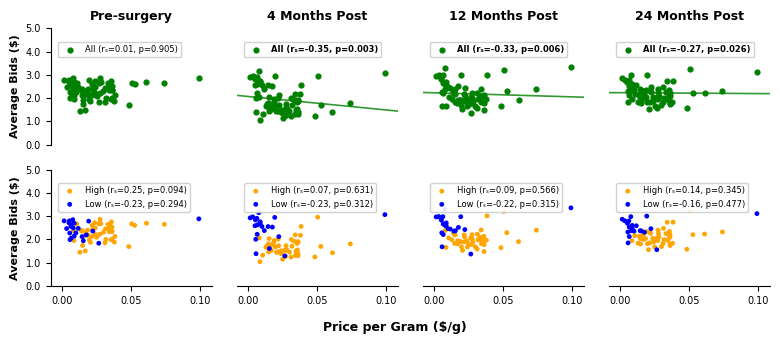


Generating plot for: Pre-surgery Liking Rating


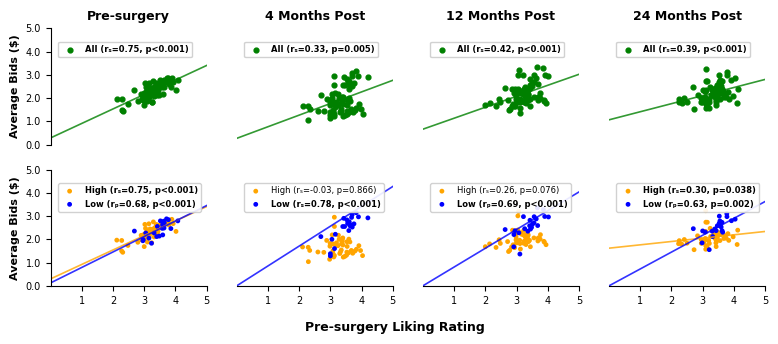


Generating plot for: True Caloric Density (kcal/g)


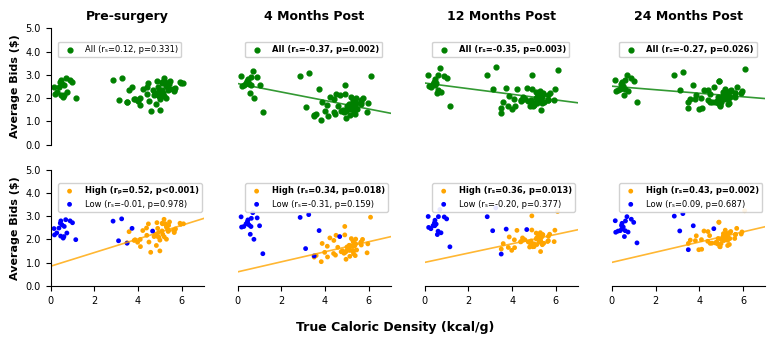


Generating plot for: Image Brightness


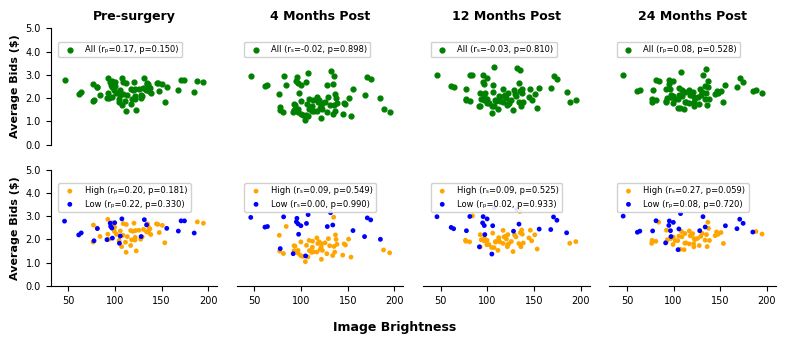


Generating plot for: Mean Blue Channel


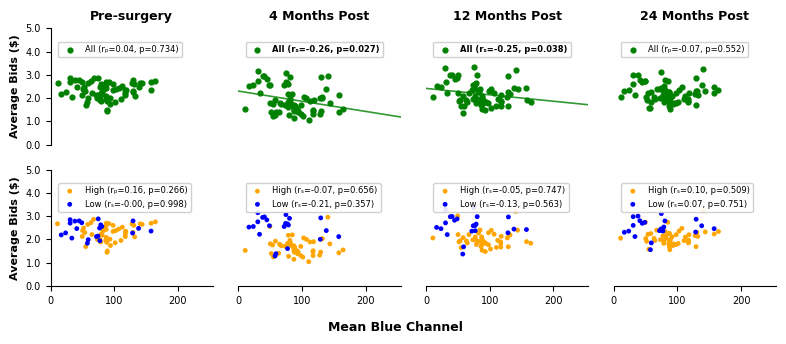


Generating plot for: Mean Green Channel


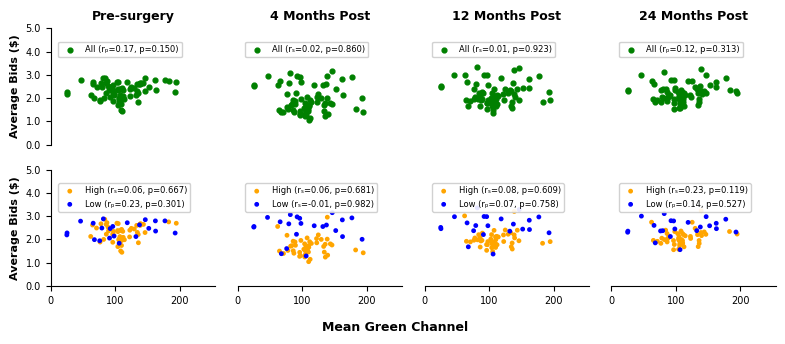


Generating plot for: Mean Red Channel


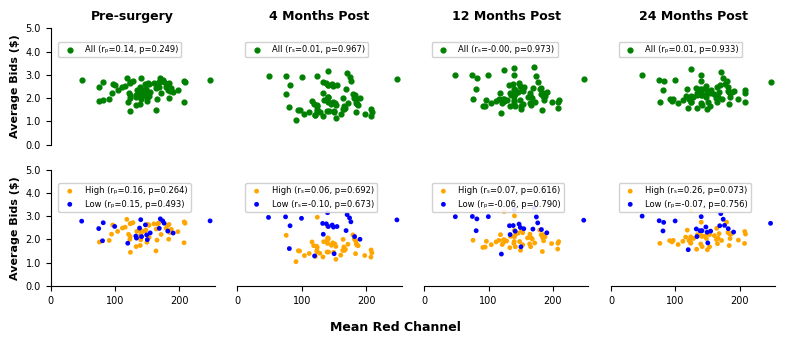


Generating plot for: Total Price ($)


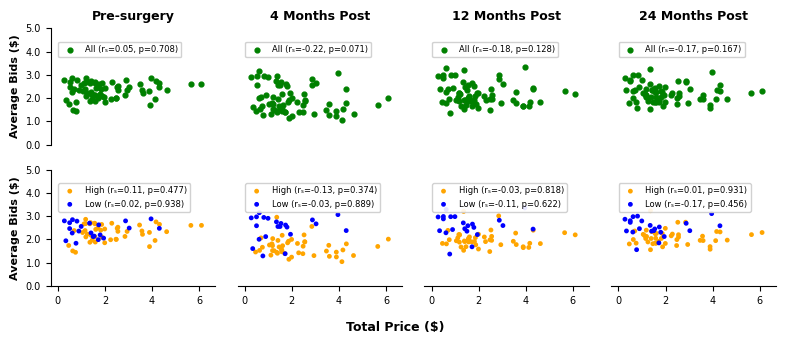


Generating plot for: Pre-surgery Estimated Calories


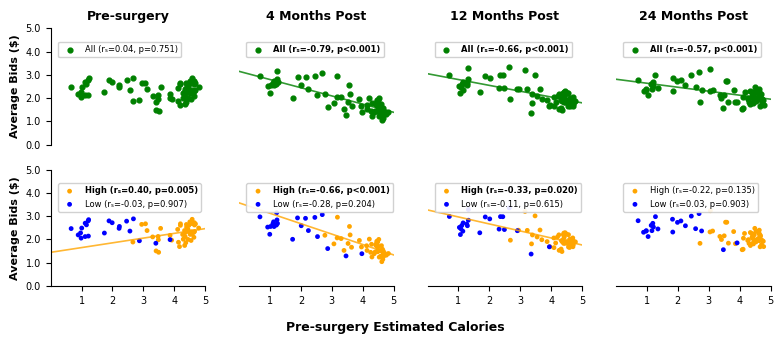


Generating plot for: Response Time (s)


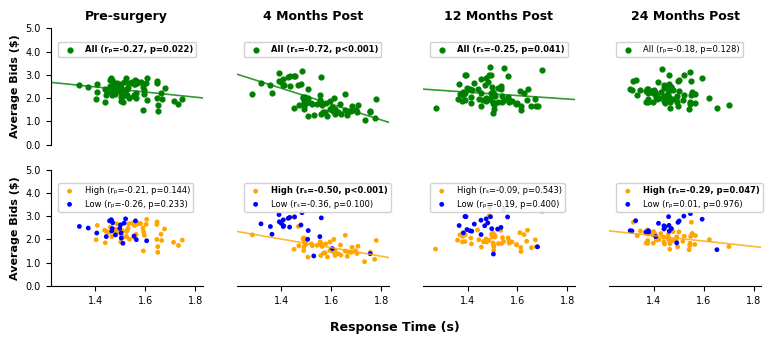


Generating plot for: Image Contrast


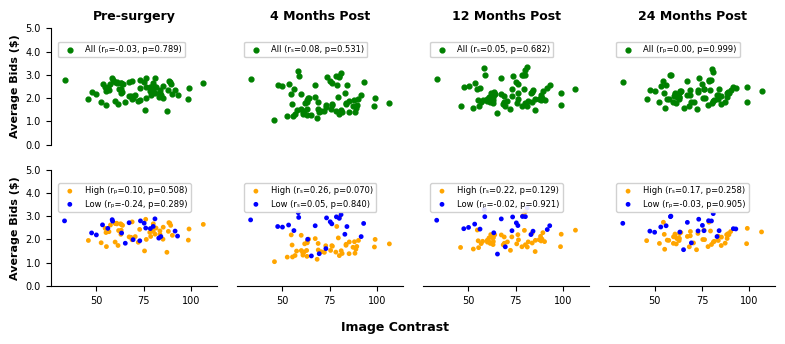


Generating plot for: Number of Object Pixels


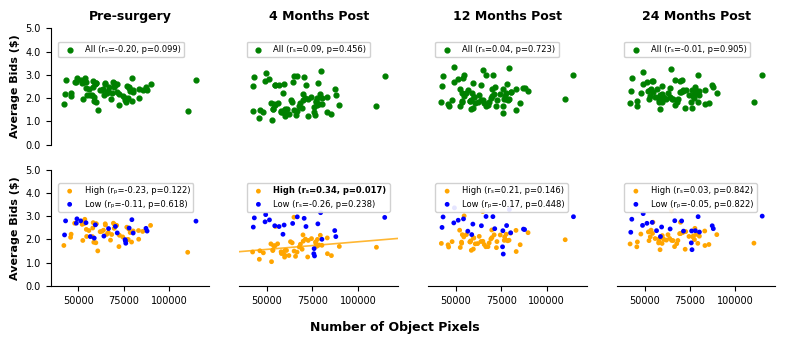


Generating plot for: Calories Shown (kcal)


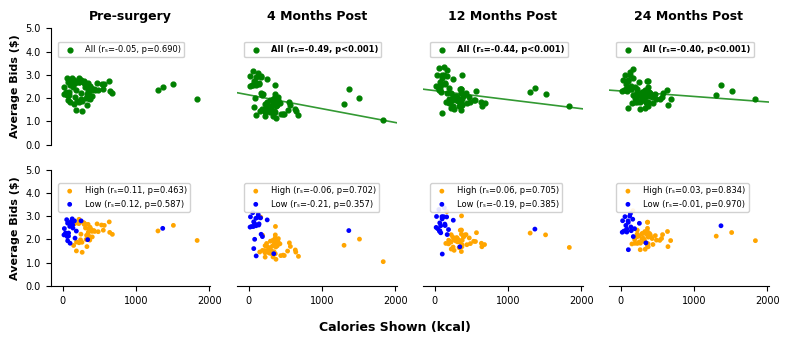


Food property plots completed!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, shapiro
from matplotlib.ticker import FormatStrFormatter

# Compute calories_shown (corrected)
df['calories_shown'] = df['Grammes montrés (Selon l\'image)'] * df['kcalreal_y']

# Prepare data - filter to rows with non-null values
# Select columns of interest for food properties
food_props = ['prix_gramme', 'like', 'kcalreal_y', 'brightness', 'mean_color_b', 
            'mean_color_g', 'mean_color_r', 'Prix', 'estcal', 'response_time', 
            'contrast', 'num_object_pixels',  'calories_shown']

# CORRECTED: Include id_participant to filter by RGC participants
df_food_props = df[['bid', 'session', 'picture', 'calories', 'id_participant'] + food_props].copy()

# Remove rows with missing values in bid (our dependent variable)
df_food_props = df_food_props.dropna(subset=['bid'])

# CORRECTED: Filter OUT RGC participants (not pictures)
print(f"Before filtering RGC participants: {len(df_food_props)} rows")
df_food_props = df_food_props[~df_food_props['id_participant'].str.lower().str.contains('rgc', na=False)]
print(f"After filtering RGC participants: {len(df_food_props)} rows")

# Filter to sessions 1-4 only
sessions_to_include = ['1', '2', '3', '4']
df_food_props = df_food_props[df_food_props['session'].isin(sessions_to_include)]

print(f"\nTotal observations with food property data (before aggregation): {len(df_food_props)}")
print(f"Sessions: {sorted(df_food_props['session'].unique())}")
print(f"Calories values: {sorted(df_food_props['calories'].unique())}")
print(f"Unique pictures: {df_food_props['picture'].nunique()}")

# Aggregation 1: By picture-session (for row 1)
print("\n" + "="*80)
print("AGGREGATING BY PICTURE-SESSION (for row 1)")
print("="*80)

# Create aggregation dict for all food properties plus bid
agg_dict = {'bid': 'mean'}
for prop in food_props:
    agg_dict[prop] = 'mean'

df_food_agg1 = df_food_props.groupby(['picture', 'session'], as_index=False).agg(agg_dict)

print(f"Aggregation 1 - Total: {len(df_food_agg1)} picture-session combinations")

# Aggregation 2: By picture-session-calories (for row 2)
print("\n" + "="*80)
print("AGGREGATING BY PICTURE-SESSION-CALORIES (for row 2)")
print("="*80)

df_food_agg2 = df_food_props.groupby(['picture', 'session', 'calories'], as_index=False).agg(agg_dict)

print(f"Aggregation 2 - Total: {len(df_food_agg2)} picture-session-calorie combinations")
print(f"Breakdown by calories:")
for cal in sorted(df_food_agg2['calories'].unique()):
    print(f"  {cal}: {len(df_food_agg2[df_food_agg2['calories'] == cal])} observations")

# Function to compute correlations with normality testing (reuse from previous code)
def compute_correlations(data, var1, var2, label):
    clean_data = data[[var1, var2]].dropna()
    if len(clean_data) > 2:
        use_pearson = True
        normality_note = ""
        
        if len(clean_data) > 3 and len(clean_data) <= 5000:
            try:
                _, p_var1 = shapiro(clean_data[var1])
                _, p_var2 = shapiro(clean_data[var2])
                
                if p_var1 < 0.05 or p_var2 < 0.05:
                    use_pearson = False
                    normality_note = f" (Shapiro p1={p_var1:.3f}, p2={p_var2:.3f})"
            except Exception as e:
                print(f"Normality test failed for {label}: {e}")
        
        pearson_r, pearson_p = pearsonr(clean_data[var1], clean_data[var2])
        spearman_r, spearman_p = spearmanr(clean_data[var1], clean_data[var2])
        
        return {
            'Comparison': label,
            'N': len(clean_data),
            'Pearson_r': pearson_r,
            'Pearson_p': pearson_p,
            'Spearman_r': spearman_r,
            'Spearman_p': spearman_p,
            'use_pearson': use_pearson,
            'normality_note': normality_note
        }
    else:
        return {
            'Comparison': label,
            'N': len(clean_data),
            'Pearson_r': np.nan,
            'Pearson_p': np.nan,
            'Spearman_r': np.nan,
            'Spearman_p': np.nan,
            'use_pearson': True,
            'normality_note': ""
        }

# Helper function to create plots for food properties
def create_food_property_scatter_plots(var_col, var_label):
    """Create a 2-row x 4-column figure for a food property variable
    Row 1: All bids combined (aggregated by picture-session)
    Row 2: Bids split by high/low calories (aggregated by picture-session-calories)
    
    var_label: e.g., 'Price per Gram', 'Liking', etc.
    """
    
    # Check if variable exists in aggregated data
    if var_col not in df_food_agg1.columns:
        print(f"Warning: {var_col} not found in aggregated data. Skipping.")
        return
    
    # Determine x-axis limits and ticks based on data range
    all_values = pd.concat([df_food_agg1[var_col], df_food_agg2[var_col]]).dropna()
    if len(all_values) == 0:
        print(f"Warning: No valid data for {var_col}. Skipping.")
        return
    
    # Set specific x-axis limits and ticks for certain variables
    if var_col in ['estcal', 'like']:
        x_limits = (0, 5)
        x_ticks = [1, 2, 3, 4, 5]
    elif var_col == 'kcalreal_y':
        x_limits = (0, 7)
        x_ticks = None  # Let matplotlib decide
    elif var_col in ['mean_color_b', 'mean_color_g', 'mean_color_r']:
        x_limits = (0, 255)
        x_ticks = None  # Let matplotlib decide
    else:
        x_min, x_max = all_values.min(), all_values.max()
        x_range = x_max - x_min
        x_limits = (x_min - 0.1 * x_range, x_max + 0.1 * x_range)
        x_ticks = None
    
    # Y-axis limits always 0 to 5 for bids
    y_limits = (0.0, 5.0)
    y_ticks = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]
    
    # Total width of 8 inches
    fig, axes = plt.subplots(2, 4, figsize=(8, 3.5))
    
    # Map session numbers to descriptive labels
    session_labels = {
        '1': 'Pre-surgery',
        '2': '4 Months Post',
        '3': '12 Months Post',
        '4': '24 Months Post'
    }
    
    # Row 1: All bids combined (picture-session aggregation)
    for idx, session in enumerate(sessions_to_include):
        ax = axes[0, idx]
        session_data = df_food_agg1[df_food_agg1['session'] == session]
        
        # Add session title only above first row
        ax.set_title(session_labels[session], fontsize=9, fontweight='bold', pad=6)
        
        if len(session_data) > 0:
            # Compute correlation first
            corr = compute_correlations(session_data, var_col, 'bid', 
                                        f'{var_label} - Session {session}')
            
            # Choose correlation based on normality test
            if corr['use_pearson']:
                r = corr['Pearson_r']
                p_val = corr['Pearson_p']
                corr_symbol = 'rₚ'
            else:
                r = corr['Spearman_r']
                p_val = corr['Spearman_p']
                corr_symbol = 'rₛ'
            
            # Format p-value: 3 decimals if < 1, else 2 decimals
            if p_val < 0.001:
                p_str = 'p<0.001'
            elif p_val < 1:
                p_str = f'p={p_val:.3f}'
            else:
                p_str = f'p={p_val:.2f}'
            
            # Create legend label with correlation info - bold if significant
            legend_label = f'All ({corr_symbol}={r:.2f}, {p_str})'
            
            # Scatter plot - green color for all foods, smaller markers
            ax.scatter(session_data[var_col], session_data['bid'],
                      alpha=1.0, s=12, color='green', label=legend_label)
            
            # Add regression line ONLY if correlation is meaningful (|r| > 0.1) or significant (p < 0.05)
            if len(session_data.dropna()) > 2 and not np.isnan(r):
                if p_val < 0.05:
                    clean_data = session_data[[var_col, 'bid']].dropna()
                    x_data = clean_data[var_col].values
                    y_data = clean_data['bid'].values
                    
                    # Linear regression
                    slope, intercept = np.polyfit(x_data, y_data, 1)
                    
                    # Create line across full x-range, clipped to y-limits
                    x_line = np.array([x_limits[0], x_limits[1]])
                    y_line = slope * x_line + intercept
                    
                    # Clip the line to y-axis limits
                    y_line = np.clip(y_line, y_limits[0], y_limits[1])
                    
                    ax.plot(x_line, y_line, color='green', alpha=0.8, linewidth=1.2)
            
            # Position legend higher up - moved up from 0.85 to 0.92
            legend = ax.legend(fontsize=6, loc='upper left', bbox_to_anchor=(0.02, 0.92), framealpha=0.9)
            # Make legend text bold if significant
            if p_val < 0.05:
                for text in legend.get_texts():
                    text.set_fontweight('bold')
        
        # Only add y-label and y-ticks to first column
        if idx == 0:
            ax.set_ylabel('Average Bids ($)', fontsize=8, fontweight='bold')
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
            ax.set_yticks(y_ticks)
            ax.tick_params(axis='y', which='major', labelsize=7)
        else:
            ax.set_yticklabels([])
            ax.spines['left'].set_visible(False)
            ax.tick_params(axis='y', which='both', left=False)
        
        # Hide x-axis completely for row 1
        ax.set_xticklabels([])
        ax.spines['bottom'].set_visible(False)
        ax.tick_params(axis='x', which='both', bottom=False)
        
        ax.set_xlim(x_limits)
        ax.set_ylim(y_limits)
        
        # Set x-axis ticks if specified
        if x_ticks is not None:
            ax.set_xticks(x_ticks)
        else:
            # Set at least 4 ticks on x-axis
            ax.locator_params(axis='x', nbins=4)
        
        # Remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    # Row 2: Bids split by high/low calories (picture-session-calorie aggregation)
    for idx, session in enumerate(sessions_to_include):
        ax = axes[1, idx]
        session_data = df_food_agg2[df_food_agg2['session'] == session]
        
        if len(session_data) > 0:
            # Split by calories (lo vs hi)
            legend_items = []
            for cal_type in ['hi', 'lo']:
                cal_data = session_data[session_data['calories'] == cal_type]
                
                if len(cal_data) > 0:
                    # Orange for high, Blue for low
                    if cal_type == 'lo':
                        color = 'blue'
                        marker = 'o'
                        cal_label = 'Low'
                    else:
                        color = 'orange'
                        marker = 'o'
                        cal_label = 'High'
                    
                    # Compute correlation
                    p_val = np.nan
                    if len(cal_data) > 2:
                        corr = compute_correlations(cal_data, var_col, 'bid', 
                                                    f'{var_label} - Session {session} - {cal_type}')
                        
                        if corr['use_pearson']:
                            r = corr['Pearson_r']
                            p_val = corr['Pearson_p']
                            corr_symbol = 'rₚ'
                        else:
                            r = corr['Spearman_r']
                            p_val = corr['Spearman_p']
                            corr_symbol = 'rₛ'
                        
                        # Format p-value: 3 decimals if < 1, else 2 decimals
                        if p_val < 0.001:
                            p_str = 'p<0.001'
                        elif p_val < 1:
                            p_str = f'p={p_val:.3f}'
                        else:
                            p_str = f'p={p_val:.2f}'
                        
                        label = f'{cal_label} ({corr_symbol}={r:.2f}, {p_str})'
                    else:
                        label = cal_label
                        r = np.nan
                    
                    # Store p_val for bold formatting
                    legend_items.append(p_val)
                    
                    # Scatter plot - smaller markers
                    ax.scatter(cal_data[var_col], cal_data['bid'],
                            alpha=1.0, s=12, color=color, marker=marker, label=label,
                            edgecolors='none')
                    
                    # Add regression line ONLY if correlation is meaningful (|r| > 0.1) or significant (p < 0.05)
                    # MOVED INSIDE THE LOOP!
                    if len(cal_data.dropna()) > 2 and not np.isnan(r):
                        if p_val < 0.05:
                            clean_data = cal_data[[var_col, 'bid']].dropna()
                            x_data = clean_data[var_col].values
                            y_data = clean_data['bid'].values
                            
                            # Linear regression
                            slope, intercept = np.polyfit(x_data, y_data, 1)
                            
                            # Create line across full x-range, clipped to y-limits
                            x_line = np.array([x_limits[0], x_limits[1]])
                            y_line = slope * x_line + intercept
                            
                            # Clip the line to y-axis limits
                            y_line = np.clip(y_line, y_limits[0], y_limits[1])
                            
                            ax.plot(x_line, y_line, color=color, linestyle='-', 
                                alpha=0.8, linewidth=1.2)
            
            # Position legend higher up - moved up from 0.85 to 0.92
            legend = ax.legend(fontsize=6, loc='upper left', bbox_to_anchor=(0.02, 0.92), framealpha=0.9)
            # Make legend text bold if significant
            for i, text in enumerate(legend.get_texts()):
                if i < len(legend_items) and not np.isnan(legend_items[i]) and legend_items[i] < 0.05:
                    text.set_fontweight('bold')
        
        # Only add y-label and y-ticks to first column
        if idx == 0:
            ax.set_ylabel('Average Bids ($)', fontsize=8, fontweight='bold')
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
            ax.set_yticks(y_ticks)
            ax.tick_params(axis='y', which='major', labelsize=7)
        else:
            ax.set_yticklabels([])
            ax.spines['left'].set_visible(False)
            ax.tick_params(axis='y', which='both', left=False)
        
        # Show x-axis for bottom row
        ax.tick_params(axis='x', which='major', labelsize=7)
        
        ax.set_xlim(x_limits)
        ax.set_ylim(y_limits)
        
        # Set x-axis ticks if specified
        if x_ticks is not None:
            ax.set_xticks(x_ticks)
        else:
            # Set at least 4 ticks on x-axis
            ax.locator_params(axis='x', nbins=4)
        
        # Remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    # Add centered x-axis label
    fig.text(0.5, 0.02, var_label, ha='center', fontsize=9, fontweight='bold')
    
    plt.tight_layout(rect=[0, 0.05, 1, 0.98])
    plt.show()

# Create figures for each food property
print("\n" + "="*80)
print("GENERATING FOOD PROPERTY PLOTS (SESSIONS 1-4 ONLY, NO RGC)")
print("="*80)

# Define nice labels for each variable
property_labels = {
    'prix_gramme': 'Price per Gram ($/g)',
    'like': 'Pre-surgery Liking Rating',
    'kcalreal_y': 'True Caloric Density (kcal/g)',
    'brightness': 'Image Brightness',
    'mean_color_b': 'Mean Blue Channel',
    'mean_color_g': 'Mean Green Channel',
    'mean_color_r': 'Mean Red Channel',
    'Prix': 'Total Price ($)',
    'estcal': 'Pre-surgery Estimated Calories',
    'response_time': 'Response Time (s)',
    'contrast': 'Image Contrast',
    'num_object_pixels': 'Number of Object Pixels',
    'calories_shown': 'Calories Shown (kcal)'
}

# Generate plots for each property
for prop in food_props:
    if prop in property_labels:
        print(f"\nGenerating plot for: {property_labels[prop]}")
        create_food_property_scatter_plots(prop, property_labels[prop])
    else:
        print(f"\nSkipping {prop} - no label defined")

print("\nFood property plots completed!")

### table of results:

In [ ]:

# ============================================================================
# GENERATE RESULTS TABLE
# ============================================================================
print("\n" + "="*80)
print("GENERATING FOOD PROPERTY CORRELATIONS RESULTS TABLE")
print("="*80)

results_table = []

# Process each food property
for prop in food_props:
    if prop not in df_food_agg1.columns:
        continue
    
    prop_label = property_labels.get(prop, prop)
    
    # Row 1: All bids combined (picture-session aggregation) by session
    for session in sessions_to_include:
        session_data = df_food_agg1[df_food_agg1['session'] == session]
        
        if len(session_data) > 0:
            corr = compute_correlations(session_data, prop, 'bid', f'{prop_label} - Session {session}')
            
            # Format p-value for display
            p_val = corr['Pearson_p'] if corr['use_pearson'] else corr['Spearman_p']
            if p_val < 0.001:
                p_str = '<0.001'
            else:
                p_str = f"{p_val:.4f}"
            
            # Get appropriate correlation
            if corr['use_pearson']:
                r_val = corr['Pearson_r']
                corr_type = 'Pearson'
            else:
                r_val = corr['Spearman_r']
                corr_type = 'Spearman'
            
            # Significance marker
            sig_marker = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else ''))
            
            results_table.append({
                'Food Property': prop_label,
                'Session': session,
                'Calorie Type': 'All',
                'Correlation Type': corr_type,
                'r': f"{r_val:.4f}",
                'p-value': p_str,
                'Sig': sig_marker,
                'N': corr['N']
            })
    
    # Row 2: Split by calories (picture-session-calorie aggregation) by session and calorie
    for session in sessions_to_include:
        session_data = df_food_agg2[df_food_agg2['session'] == session]
        
        for cal_type in ['lo', 'hi']:
            cal_data = session_data[session_data['calories'] == cal_type]
            
            if len(cal_data) > 0:
                corr = compute_correlations(cal_data, prop, 'bid', 
                                          f'{prop_label} - Session {session} - {cal_type}')
                
                # Format p-value for display
                p_val = corr['Pearson_p'] if corr['use_pearson'] else corr['Spearman_p']
                if p_val < 0.001:
                    p_str = '<0.001'
                else:
                    p_str = f"{p_val:.4f}"
                
                # Get appropriate correlation
                if corr['use_pearson']:
                    r_val = corr['Pearson_r']
                    corr_type = 'Pearson'
                else:
                    r_val = corr['Spearman_r']
                    corr_type = 'Spearman'
                
                # Significance marker
                sig_marker = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else ''))
                
                cal_label = 'Low Calorie' if cal_type == 'lo' else 'High Calorie'
                
                results_table.append({
                    'Food Property': prop_label,
                    'Session': session,
                    'Calorie Type': cal_label,
                    'Correlation Type': corr_type,
                    'r': f"{r_val:.4f}",
                    'p-value': p_str,
                    'Sig': sig_marker,
                    'N': corr['N']
                })

# Convert to DataFrame and display
results_df = pd.DataFrame(results_table)

print("\n" + "="*80)
print("FOOD PROPERTY CORRELATIONS WITH BIDS - COMPLETE RESULTS")
print("="*80)
print("\nSession Key: 1=Pre-surgery, 2=4 Months Post, 3=12 Months Post, 4=24 Months Post")
print("Significance: *** p<0.001, ** p<0.01, * p<0.05\n")

# Display full table
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
print(results_df.to_string(index=False))

# Summary statistics by property
print("\n" + "="*80)
print("SUMMARY: Significant Correlations by Property")
print("="*80)
significant = results_df[results_df['Sig'] != '']
if len(significant) > 0:
    for prop in food_props:
        prop_label = property_labels.get(prop, prop)
        prop_sig = significant[significant['Food Property'] == prop_label]
        if len(prop_sig) > 0:
            print(f"\n{prop_label}:")
            print(f"  Total significant correlations: {len(prop_sig)}")
            for idx, row in prop_sig.iterrows():
                print(f"    Session {row['Session']} - {row['Calorie Type']}: r={row['r']}, p={row['p-value']} {row['Sig']} (n={row['N']})")
else:
    print("No significant correlations found.")

# Count summary by session
print("\n" + "="*80)
print("SUMMARY: Significant Correlations by Session")
print("="*80)
for session in sessions_to_include:
    session_sig = significant[significant['Session'] == session]
    if len(session_sig) > 0:
        print(f"\nSession {session}: {len(session_sig)} significant correlations")
        for idx, row in session_sig.iterrows():
            print(f"  {row['Food Property']} ({row['Calorie Type']}): r={row['r']}, p={row['p-value']} {row['Sig']}")
    else:
        print(f"\nSession {session}: No significant correlations")

print("\n" + "="*80)
print("Results table generation completed!")
print("="*80)


GENERATING FOOD PROPERTY CORRELATIONS RESULTS TABLE

FOOD PROPERTY CORRELATIONS WITH BIDS - COMPLETE RESULTS

Session Key: 1=Pre-surgery, 2=4 Months Post, 3=12 Months Post, 4=24 Months Post
Significance: *** p<0.001, ** p<0.01, * p<0.05

                 Food Property Session Calorie Type Correlation Type       r p-value Sig  N
          Price per Gram ($/g)       1          All         Spearman  0.0146  0.9052     69
          Price per Gram ($/g)       2          All         Spearman -0.3519  0.0030  ** 69
          Price per Gram ($/g)       3          All         Spearman -0.3250  0.0064  ** 69
          Price per Gram ($/g)       4          All         Spearman -0.2671  0.0265   * 69
          Price per Gram ($/g)       1  Low Calorie         Spearman -0.2344  0.2937     22
          Price per Gram ($/g)       1 High Calorie         Spearman  0.2475  0.0935     47
          Price per Gram ($/g)       2  Low Calorie         Spearman -0.2259  0.3120     22
          Price per Gram 

## with qc final (n = 57) comparison of food properties

df_final shape: (507, 10)
Number of valid (participant, session) combinations in df_final: 199
Sample valid combinations: [('rnd024', '2'), ('rnd030', '1'), ('rcx136', '3'), ('rcx200', '1'), ('rnd073', '4')]

Before filtering to df_final combinations: 43569 rows
After filtering to df_final combinations: 26727 rows
After filtering to sessions 1-4: 26727 rows
Unique participants: 57
Unique sessions: ['1', '2', '3', '4']

Aggregating data by picture...
Filtered data (valid combinations only): 26727 rows
Aggregated data: 70 rows (unique pictures)
Calories distribution: {'hi': 48, 'lo': 22}

FIGURE 1: VISUAL PROPERTIES (FILTERED TO DF_FINAL COMBINATIONS)

Processing: Red Channel
  n_high=48, n_low=22
  Normality test - High: p=0.6911, Low: p=0.5612
  Equal variance test: p=0.2505
  Test: t-test, p=0.4729

Processing: Green Channel
  n_high=48, n_low=22
  Normality test - High: p=0.0293, Low: p=0.7407
  Test: Mann-Whitney, p=0.5649

Processing: Blue Channel
  n_high=48, n_low=22
  Normality 

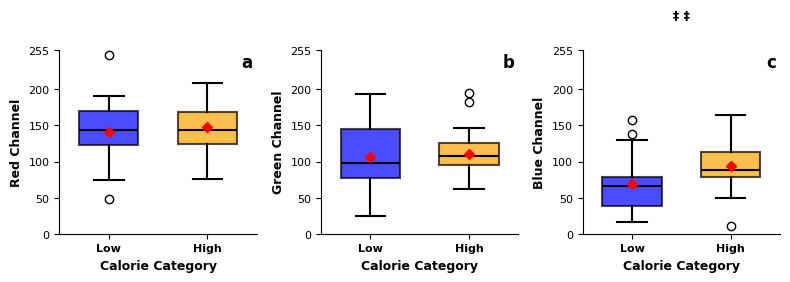


Visual Properties - Row 1 completed

Processing: Object Size (kpixels)
  n_high=48, n_low=22
  Normality test - High: p=0.1427, Low: p=0.2739
  Equal variance test: p=0.1314
  Test: t-test, p=0.6336

Processing: Brightness
  n_high=48, n_low=22
  Normality test - High: p=0.0616, Low: p=0.2386
  Equal variance test: p=0.0280
  Test: Welch's t, p=0.4213

Processing: Contrast
  n_high=48, n_low=22
  Normality test - High: p=0.3689, Low: p=0.8291
  Equal variance test: p=0.8230
  Test: t-test, p=0.2327


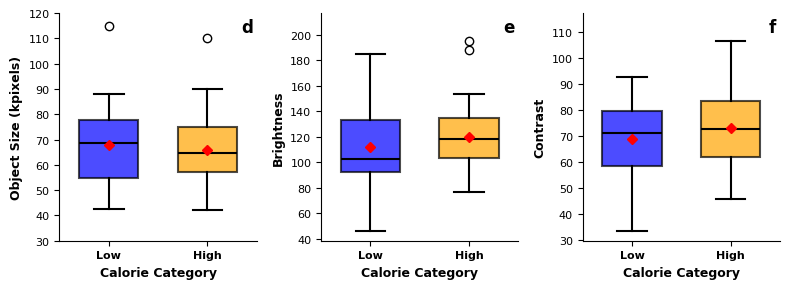


Visual Properties - Row 2 completed

FIGURE 2: CALORIC PROPERTIES (FILTERED TO DF_FINAL COMBINATIONS)

Processing: True Caloric Density (kcal/g)
  n_high=47, n_low=22
  Normality test - High: p=0.1232, Low: p=0.0001
  Test: Mann-Whitney, p=0.0000

Processing: Estimated Caloric Density
  n_high=48, n_low=22
  Normality test - High: p=0.0000, Low: p=0.0244
  Test: Mann-Whitney, p=0.0000

Processing: Calories Shown (kcal)
  n_high=47, n_low=22
  Normality test - High: p=0.0000, Low: p=0.0000
  Test: Mann-Whitney, p=0.0000


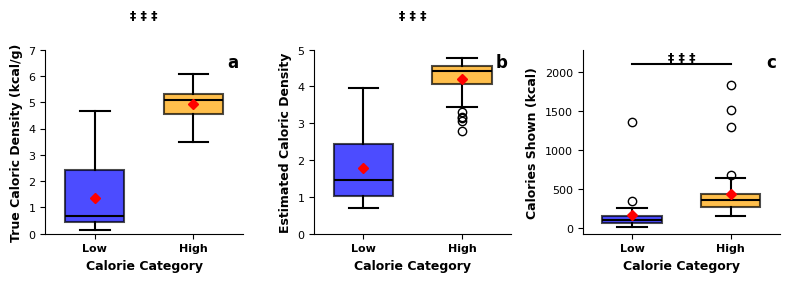


Caloric Properties - Row 1 completed

FIGURE 3: BEHAVIORAL PROPERTIES (FILTERED TO DF_FINAL COMBINATIONS)

Processing: Response Time (s)
  n_high=48, n_low=22
  Normality test - High: p=0.5694, Low: p=0.0393
  Test: Mann-Whitney, p=0.0000

Processing: Pre-surgery Liking Rating
  n_high=48, n_low=22
  Normality test - High: p=0.1108, Low: p=0.2790
  Equal variance test: p=0.0887
  Test: t-test, p=0.0415


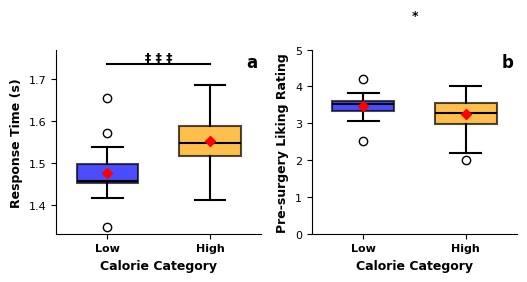


Behavioral Properties - Row 1 completed

FIGURE 4: ECONOMIC PROPERTIES (FILTERED TO DF_FINAL COMBINATIONS)

Processing: Retail Price per Gram ($/g)
  n_high=47, n_low=22
  Normality test - High: p=0.0060, Low: p=0.0000
  Test: Mann-Whitney, p=0.0000

Processing: Retail Price ($)
  n_high=47, n_low=22
  Normality test - High: p=0.0009, Low: p=0.0070
  Test: Mann-Whitney, p=0.0127

Processing: Mass Shown (g)
  n_high=47, n_low=22
  Normality test - High: p=0.0000, Low: p=0.0136
  Test: Mann-Whitney, p=0.0041


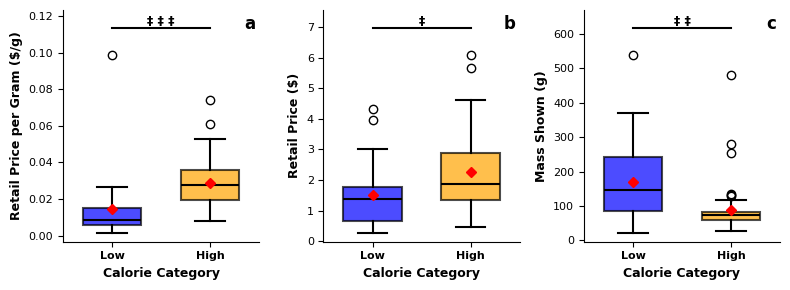


Economic Properties - Row 1 completed

COMPREHENSIVE STATISTICAL TEST RESULTS: High Calorie vs Low Calorie Foods
(Aggregated by Picture, Filtered to df_final participant-session combinations)
               Figure                      Property         Test Statistic p-value  n_high  n_low p_norm_high p_norm_low p_equal_var
    Visual Properties                   Red Channel       t-test     0.722  0.4729      48     22      0.6911     0.5612      0.2505
    Visual Properties                 Green Channel Mann-Whitney   574.000  0.5649      48     22      0.0293     0.7407         N/A
    Visual Properties                  Blue Channel Mann-Whitney   780.000  0.0015      48     22      0.6366     0.0345         N/A
    Visual Properties         Object Size (kpixels)       t-test    -0.479  0.6336      48     22      0.1427     0.2739      0.1314
    Visual Properties                    Brightness    Welch's t     0.816  0.4213      48     22      0.0616     0.2386      0.0280
    Visua

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FormatStrFormatter, FixedLocator
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')



print(f"df_final shape: {df_final.shape}")

# Create valid combinations - convert sess to string to match df session format
valid_combinations = set(
    df_final[['Subj', 'sess']].apply(lambda row: (row['Subj'].lower(), str(row['sess'])), axis=1)
)

print(f"Number of valid (participant, session) combinations in df_final: {len(valid_combinations)}")
print(f"Sample valid combinations: {list(valid_combinations)[:5]}")

# Define significance symbols per test type
test_symbols = {
    't-test': '*',           # Asterisk for t-test
    "Welch's t": '†',        # Dagger for Welch's t-test
    'Mann-Whitney': '‡'      # Double dagger for Mann-Whitney
}

# Define nice labels for each property
property_labels = {
    'prix_gramme': 'Retail Price per Gram ($/g)',
    'like': 'Pre-surgery Liking Rating',
    'kcalreal_y': 'True Caloric Density (kcal/g)',
    'brightness': 'Brightness',
    'mean_color_b': 'Blue Channel',
    'mean_color_g': 'Green Channel',
    'mean_color_r': 'Red Channel',
    'Prix': 'Retail Price ($)',
    'estcal': 'Estimated Caloric Density',
    'contrast': 'Contrast',
    'num_object_pixels': 'Object Size (kpixels)',
    'calories_shown': 'Calories Shown (kcal)',
    'response_time': 'Response Time (s)',
    'Grammes montrés (Selon l\'image)': 'Mass Shown (g)'
}

# Define fixed y-axis limits for specific properties
y_axis_limits = {
    'mean_color_r': (0, 255),
    'mean_color_g': (0, 255),
    'mean_color_b': (0, 255),
    'estcal': (0, 5),
    'like': (0, 5),
    'kcalreal_y': (0, 7),
    'num_object_pixels': (30, 120)
}

# Define y-axis ticks for specific properties
y_axis_ticks = {
    'mean_color_r': [0, 50, 100, 150, 200, 255],
    'mean_color_g': [0, 50, 100, 150, 200, 255],
    'mean_color_b': [0, 50, 100, 150, 200, 255],
    'estcal': [0, 1, 2, 3, 4, 5],
    'like': [0, 1, 2, 3, 4, 5],
    'num_object_pixels': [30, 40, 50, 60, 70, 80, 90, 100, 110, 120]
}

# Filter data: FIRST filter to valid combinations from df_final
print(f"\nBefore filtering to df_final combinations: {len(df)} rows")

# Ensure session is string for comparison
df_filtered = df.copy()
df_filtered['session'] = df_filtered['session'].astype(str)

# Filter to only valid (participant, session) combinations from df_final
df_filtered = df_filtered[
    df_filtered.apply(lambda row: (row['id_participant'].lower(), str(row['session'])) in valid_combinations, axis=1)
]

print(f"After filtering to df_final combinations: {len(df_filtered)} rows")

# Keep only sessions 1-4 (should already be satisfied by df_final, but just to be sure)
df_filtered = df_filtered[df_filtered['session'].isin(['1', '2', '3', '4'])]

print(f"After filtering to sessions 1-4: {len(df_filtered)} rows")
print(f"Unique participants: {df_filtered['id_participant'].nunique()}")
print(f"Unique sessions: {sorted(df_filtered['session'].unique())}")

# Convert num_object_pixels to kpixels (divide by 1000)
df_filtered['num_object_pixels'] = df_filtered['num_object_pixels'] / 1000

# Aggregate by picture (mean across all participants and sessions)
print("\nAggregating data by picture...")
all_properties = ['mean_color_r', 'mean_color_g', 'mean_color_b', 'brightness', 'contrast', 
                 'num_object_pixels','kcalreal_y', 'estcal', 'calories_shown', 
                 'response_time', 'like','prix_gramme', 'Prix', 'Grammes montrés (Selon l\'image)']

agg_dict = {}
for prop in all_properties:
    agg_dict[prop] = 'mean'
agg_dict['calories'] = 'first'

df_agg = df_filtered.groupby('picture', as_index=False).agg(agg_dict)

print(f"Filtered data (valid combinations only): {len(df_filtered)} rows")
print(f"Aggregated data: {len(df_agg)} rows (unique pictures)")
print(f"Calories distribution: {df_agg['calories'].value_counts().to_dict()}")

# Function to perform normality test
def test_normality(data):
    """Shapiro-Wilk test for normality. Returns p-value."""
    if len(data) < 3 or len(data) > 5000:
        return np.nan
    try:
        _, p = shapiro(data)
        return p
    except:
        return np.nan

# Function to perform equality of variances test
def test_equal_variances(data1, data2):
    """Levene's test for equality of variances. Returns p-value."""
    if len(data1) < 2 or len(data2) < 2:
        return np.nan
    try:
        _, p = levene(data1, data2)
        return p
    except:
        return np.nan

# Function to determine which test to use and perform it
def perform_statistical_test(data_hi, data_lo):
    """
    Determine appropriate test based on normality and variance equality.
    Returns: (test_name, statistic, p_value, p_norm_hi, p_norm_lo, p_var)
    """
    p_norm_hi = test_normality(data_hi)
    p_norm_lo = test_normality(data_lo)
    
    print(f"  Normality test - High: p={p_norm_hi:.4f}, Low: p={p_norm_lo:.4f}")
    
    both_normal = not np.isnan(p_norm_hi) and not np.isnan(p_norm_lo) and (p_norm_hi > 0.05) and (p_norm_lo > 0.05)
    
    if both_normal:
        p_var = test_equal_variances(data_hi, data_lo)
        print(f"  Equal variance test: p={p_var:.4f}")
        
        if p_var > 0.05:
            stat, p = ttest_ind(data_hi, data_lo, equal_var=True)
            return ('t-test', stat, p, p_norm_hi, p_norm_lo, p_var)
        else:
            stat, p = ttest_ind(data_hi, data_lo, equal_var=False)
            return ("Welch's t", stat, p, p_norm_hi, p_norm_lo, p_var)
    else:
        stat, p = mannwhitneyu(data_hi, data_lo, alternative='two-sided')
        return ('Mann-Whitney', stat, p, p_norm_hi, p_norm_lo, np.nan)

# Colors for box plots
colors = {'hi': 'orange', 'lo': 'blue'}

# Store all statistical results
all_stats_results = []

def create_figure(properties_rows, figure_title):
    """Create a figure with multiple rows of properties"""
    global all_stats_results
    
    panel_counter = 0
    
    for row_idx, row_properties in enumerate(properties_rows):
        n_plots_in_row = len(row_properties)
        
        # Create figure for this row - width 8 inches for Word portrait
        fig, axes = plt.subplots(1, 3, figsize=(8, 3))
        
        for idx, prop in enumerate(row_properties):
            ax = axes[idx]
            
            print(f"\nProcessing: {property_labels[prop]}")
            
            data = df_agg[['calories', prop]].dropna()
            
            if len(data) > 0:
                data_hi = data[data['calories'] == 'hi'][prop].values
                data_lo = data[data['calories'] == 'lo'][prop].values
                
                print(f"  n_high={len(data_hi)}, n_low={len(data_lo)}")
                
                if len(data_hi) > 0 and len(data_lo) > 0:
                    test_name, stat, p_value, p_norm_hi, p_norm_lo, p_var = perform_statistical_test(data_hi, data_lo)
                    
                    print(f"  Test: {test_name}, p={p_value:.4f}")
                    
                    all_stats_results.append({
                        'Figure': figure_title,
                        'Property': property_labels[prop],
                        'Test': test_name,
                        'Statistic': f'{stat:.3f}',
                        'p-value': f'{p_value:.4f}',
                        'n_high': len(data_hi),
                        'n_low': len(data_lo),
                        'p_norm_high': f'{p_norm_hi:.4f}' if not np.isnan(p_norm_hi) else 'N/A',
                        'p_norm_low': f'{p_norm_lo:.4f}' if not np.isnan(p_norm_lo) else 'N/A',
                        'p_equal_var': f'{p_var:.4f}' if not np.isnan(p_var) else 'N/A'
                    })
                    
                    box_data = [data_lo, data_hi]
                    
                    bp = ax.boxplot(box_data, positions=[0, 1], widths=0.6,
                                   patch_artist=True, showmeans=True,
                                   meanprops=dict(marker='D', markerfacecolor='red', markeredgecolor='red', markersize=5),
                                   medianprops=dict(color='black', linewidth=1.5),
                                   boxprops=dict(linewidth=1.5),
                                   whiskerprops=dict(linewidth=1.5),
                                   capprops=dict(linewidth=1.5))
                    
                    bp['boxes'][0].set_facecolor(colors['lo'])
                    bp['boxes'][0].set_alpha(0.7)
                    bp['boxes'][1].set_facecolor(colors['hi'])
                    bp['boxes'][1].set_alpha(0.7)
                    
                    if prop in y_axis_limits:
                        y_min, y_max = y_axis_limits[prop]
                        y_range = y_max - y_min
                    else:
                        y_max = max(data_hi.max(), data_lo.max())
                        y_min = min(data_hi.min(), data_lo.min())
                        y_range = y_max - y_min
                    
                    base_symbol = test_symbols.get(test_name, '*')
                    
                    if p_value < 0.001:
                        sig_marker = ' '.join([base_symbol] * 3)
                    elif p_value < 0.01:
                        sig_marker = ' '.join([base_symbol] * 2)
                    elif p_value < 0.05:
                        sig_marker = base_symbol
                    else:
                        sig_marker = 'n.s.'
                    
                    # Set y-limits and ticks BEFORE adding significance bar
                    if prop in y_axis_limits:
                        # For properties with fixed limits, always use those limits
                        ax.set_ylim(y_min, y_max)
                    
                    # Set y-axis ticks - do this AFTER setting ylim
                    if prop in y_axis_ticks:
                        ax.yaxis.set_major_locator(FixedLocator(y_axis_ticks[prop]))
                        ax.set_yticks(y_axis_ticks[prop])
                    
                    # Now add significance bar if needed (but don't change ylim for color channels)
                    if p_value < 0.05:
                        y_bar = y_max + 0.15 * y_range
                        ax.plot([0, 1], [y_bar, y_bar], 'k-', linewidth=1.5)
                        ax.text(0.5, y_bar, sig_marker, ha='center', va='bottom', fontsize=9, fontweight='bold')
                        
                        # Only expand ylim for properties WITHOUT fixed limits
                        if prop not in y_axis_limits:
                            ax.set_ylim(y_min - 0.05 * y_range, y_max + 0.25 * y_range)
                    else:
                        # Only expand ylim for properties WITHOUT fixed limits
                        if prop not in y_axis_limits:
                            ax.set_ylim(y_min - 0.05 * y_range, y_max + 0.15 * y_range)
                
                ax.set_xticks([0, 1])
                ax.set_xticklabels(['Low', 'High'], fontsize=8, fontweight='bold')
                ax.set_xlabel('Calorie Category', fontsize=9, fontweight='bold')
                ax.set_ylabel(property_labels[prop], fontsize=9, fontweight='bold')
                ax.tick_params(axis='y', which='major', labelsize=8)
                
                ax.text(0.98, 0.98, chr(97 + panel_counter), transform=ax.transAxes,
                        fontsize=12, fontweight='bold', va='top', ha='right')
                panel_counter += 1
                
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)
            else:
                ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, 
                       ha='center', va='center', fontsize=10)
                ax.set_xticks([])
                ax.set_yticks([])
        
        for idx in range(n_plots_in_row, 3):
            axes[idx].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        print(f"\n{figure_title} - Row {row_idx + 1} completed\n" + "="*80)

# FIGURE 1: VISUAL PROPERTIES
print("\n" + "="*80)
print("FIGURE 1: VISUAL PROPERTIES (FILTERED TO DF_FINAL COMBINATIONS)")
print("="*80)
visual_properties_rows = [
    ['mean_color_r', 'mean_color_g', 'mean_color_b'],           # Row 1: Channels (panels a-c)
    ['num_object_pixels', 'brightness', 'contrast']
]
create_figure(visual_properties_rows, "Visual Properties")

# FIGURE 2: CALORIC PROPERTIES
print("\n" + "="*80)
print("FIGURE 2: CALORIC PROPERTIES (FILTERED TO DF_FINAL COMBINATIONS)")
print("="*80)
caloric_properties_rows = [
    ['kcalreal_y', 'estcal', 'calories_shown']                   # Row 1: Calories (panels a-c)
]
create_figure(caloric_properties_rows, "Caloric Properties")

# FIGURE 3: BEHAVIORAL PROPERTIES
print("\n" + "="*80)
print("FIGURE 3: BEHAVIORAL PROPERTIES (FILTERED TO DF_FINAL COMBINATIONS)")
print("="*80)
behavioral_properties_rows = [
    ['response_time', 'like']                                    # Row 1: Behavioral (panels a-b)
]
create_figure(behavioral_properties_rows, "Behavioral Properties")

# FIGURE 4: ECONOMIC PROPERTIES
print("\n" + "="*80)
print("FIGURE 4: ECONOMIC PROPERTIES (FILTERED TO DF_FINAL COMBINATIONS)")
print("="*80)
economic_properties_rows = [
    ['prix_gramme', 'Prix', 'Grammes montrés (Selon l\'image)'] # Row 1: Economic (panels a-c)
]
create_figure(economic_properties_rows, "Economic Properties")

# Print comprehensive statistical results table
print("\n" + "="*120)
print("COMPREHENSIVE STATISTICAL TEST RESULTS: High Calorie vs Low Calorie Foods")
print("(Aggregated by Picture, Filtered to df_final participant-session combinations)")
print("="*120)

stats_df = pd.DataFrame(all_stats_results)
print(stats_df.to_string(index=False))

# Print interpretation guide
print("\n" + "="*120)
print("TEST SELECTION CRITERIA:")
print("="*120)
print("1. If both groups are normally distributed (Shapiro-Wilk p > 0.05):")
print("   - AND variances are equal (Levene's test p > 0.05) → Independent t-test")
print("   - AND variances are unequal (Levene's test p ≤ 0.05) → Welch's t-test")
print("2. If at least one group is non-normal (Shapiro-Wilk p ≤ 0.05) → Mann-Whitney U test")
print("\nSIGNIFICANCE SYMBOLS:")
print("  t-test:       * p<0.05, * * p<0.01, * * * p<0.001")
print("  Welch's t:    † p<0.05, † † p<0.01, † † † p<0.001")
print("  Mann-Whitney: ‡ p<0.05, ‡ ‡ p<0.01, ‡ ‡ ‡ p<0.001")
print("  n.s. = not significant (p ≥ 0.05)")
print("\nDATA FILTERING:")
print(f"  Only includes data from {len(valid_combinations)} valid (participant, session) combinations in df_final")
print("="*120)

## response time all sessions


RESPONSE TIME ANALYSIS - SESSION 1 (Session 1)
Number of valid participants in session 1: 57

Before filtering to df_final participants: 12903 rows
After filtering to df_final participants: 7812 rows
Unique participants: 57

Aggregating data by picture (session 1 only)...
Session 1 data: 7812 rows
Aggregated data: 70 rows (unique pictures)
Calories distribution: {'hi': 48, 'lo': 22}

Response Time (Session 1):
  n_high=48, n_low=22
  High calorie: mean=1.569s, std=0.082s
  Low calorie:  mean=1.505s, std=0.066s
  Normality test - High: p=0.3890, Low: p=0.8020
  Equal variance test: p=0.1251

  Test: t-test
  Statistic: 3.198
  p-value: 0.0021
  Significance: **


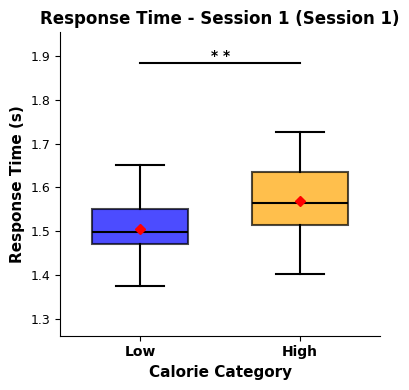


STATISTICAL TEST RESULTS SUMMARY
Property: Response Time (Session 1 Session 1)
Test: t-test
Statistic: 3.198
p-value: 0.0021
n_high: 48
n_low: 22
p_norm_high: 0.3890
p_norm_low: 0.8020
p_equal_var: 0.1251

SIGNIFICANCE SYMBOLS:
  t-test:       * p<0.05, * * p<0.01, * * * p<0.001
  Welch's t:    † p<0.05, † † p<0.01, † † † p<0.001
  Mann-Whitney: ‡ p<0.05, ‡ ‡ p<0.01, ‡ ‡ ‡ p<0.001
  n.s. = not significant (p ≥ 0.05)

RESPONSE TIME ANALYSIS - SESSION 2 (Session 2)
Number of valid participants in session 2: 52

Before filtering to df_final participants: 11501 rows
After filtering to df_final participants: 6979 rows
Unique participants: 52

Aggregating data by picture (session 2 only)...
Session 2 data: 6979 rows
Aggregated data: 70 rows (unique pictures)
Calories distribution: {'hi': 48, 'lo': 22}

Response Time (Session 2):
  n_high=48, n_low=22
  High calorie: mean=1.587s, std=0.101s
  Low calorie:  mean=1.452s, std=0.103s
  Normality test - High: p=0.7456, Low: p=0.0305

  Test: Mann

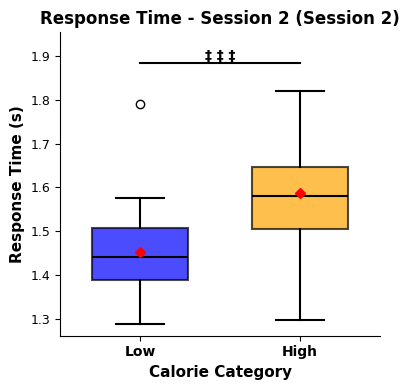


STATISTICAL TEST RESULTS SUMMARY
Property: Response Time (Session 2 Session 2)
Test: Mann-Whitney
Statistic: 897.000
p-value: 0.0000
n_high: 48
n_low: 22
p_norm_high: 0.7456
p_norm_low: 0.0305
p_equal_var: N/A

SIGNIFICANCE SYMBOLS:
  t-test:       * p<0.05, * * p<0.01, * * * p<0.001
  Welch's t:    † p<0.05, † † p<0.01, † † † p<0.001
  Mann-Whitney: ‡ p<0.05, ‡ ‡ p<0.01, ‡ ‡ ‡ p<0.001
  n.s. = not significant (p ≥ 0.05)

RESPONSE TIME ANALYSIS - SESSION 3 (Session 3)
Number of valid participants in session 3: 46

Before filtering to df_final participants: 8273 rows
After filtering to df_final participants: 6146 rows
Unique participants: 46

Aggregating data by picture (session 3 only)...
Session 3 data: 6146 rows
Aggregated data: 70 rows (unique pictures)
Calories distribution: {'hi': 48, 'lo': 22}

Response Time (Session 3):
  n_high=48, n_low=22
  High calorie: mean=1.529s, std=0.098s
  Low calorie:  mean=1.468s, std=0.072s
  Normality test - High: p=0.5058, Low: p=0.5858
  Equal v

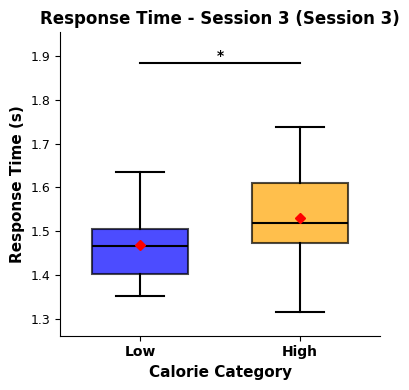


STATISTICAL TEST RESULTS SUMMARY
Property: Response Time (Session 3 Session 3)
Test: t-test
Statistic: 2.587
p-value: 0.0118
n_high: 48
n_low: 22
p_norm_high: 0.5058
p_norm_low: 0.5858
p_equal_var: 0.1731

SIGNIFICANCE SYMBOLS:
  t-test:       * p<0.05, * * p<0.01, * * * p<0.001
  Welch's t:    † p<0.05, † † p<0.01, † † † p<0.001
  Mann-Whitney: ‡ p<0.05, ‡ ‡ p<0.01, ‡ ‡ ‡ p<0.001
  n.s. = not significant (p ≥ 0.05)

RESPONSE TIME ANALYSIS - SESSION 4 (Session 4)
Number of valid participants in session 4: 44

Before filtering to df_final participants: 8194 rows
After filtering to df_final participants: 5790 rows
Unique participants: 44

Aggregating data by picture (session 4 only)...
Session 4 data: 5790 rows
Aggregated data: 70 rows (unique pictures)
Calories distribution: {'hi': 48, 'lo': 22}

Response Time (Session 4):
  n_high=48, n_low=22
  High calorie: mean=1.512s, std=0.105s
  Low calorie:  mean=1.472s, std=0.094s
  Normality test - High: p=0.1605, Low: p=0.8641
  Equal varian

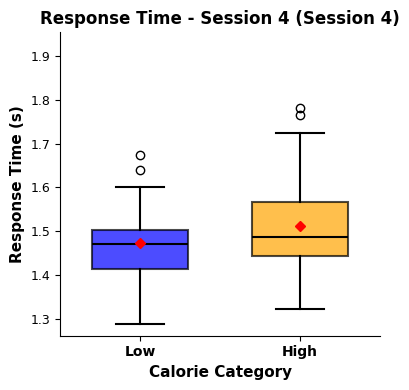


STATISTICAL TEST RESULTS SUMMARY
Property: Response Time (Session 4 Session 4)
Test: t-test
Statistic: 1.493
p-value: 0.1401
n_high: 48
n_low: 22
p_norm_high: 0.1605
p_norm_low: 0.8641
p_equal_var: 0.5733

SIGNIFICANCE SYMBOLS:
  t-test:       * p<0.05, * * p<0.01, * * * p<0.001
  Welch's t:    † p<0.05, † † p<0.01, † † † p<0.001
  Mann-Whitney: ‡ p<0.05, ‡ ‡ p<0.01, ‡ ‡ ‡ p<0.001
  n.s. = not significant (p ≥ 0.05)

ANALYSIS COMPLETE FOR ALL SESSIONS


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FormatStrFormatter, FixedLocator
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu
import warnings

warnings.filterwarnings('ignore')

# Get unique sessions and filter out 'x'
sessions = sorted([s for s in df['session'].unique() if s != 'x'])

# Define helper functions
def test_normality(data):
    if len(data) < 3 or len(data) > 5000:
        return np.nan
    try:
        _, p = shapiro(data)
        return p
    except:
        return np.nan

def test_equal_variances(data1, data2):
    if len(data1) < 2 or len(data2) < 2:
        return np.nan
    try:
        _, p = levene(data1, data2)
        return p
    except:
        return np.nan

def perform_statistical_test(data_hi, data_lo):
    p_norm_hi = test_normality(data_hi)
    p_norm_lo = test_normality(data_lo)
    
    print(f"  Normality test - High: p={p_norm_hi:.4f}, Low: p={p_norm_lo:.4f}")
    
    both_normal = not np.isnan(p_norm_hi) and not np.isnan(p_norm_lo) and (p_norm_hi > 0.05) and (p_norm_lo > 0.05)
    
    if both_normal:
        p_var = test_equal_variances(data_hi, data_lo)
        print(f"  Equal variance test: p={p_var:.4f}")
        
        if p_var > 0.05:
            stat, p = ttest_ind(data_hi, data_lo, equal_var=True)
            return ('t-test', stat, p, p_norm_hi, p_norm_lo, p_var)
        else:
            stat, p = ttest_ind(data_hi, data_lo, equal_var=False)
            return ("Welch's t", stat, p, p_norm_hi, p_norm_lo, p_var)
    else:
        stat, p = mannwhitneyu(data_hi, data_lo, alternative='two-sided')
        return ('Mann-Whitney', stat, p, p_norm_hi, p_norm_lo, np.nan)

# FIRST PASS: Calculate global y-axis range across all sessions
global_y_min = float('inf')
global_y_max = float('-inf')

for session in sessions:
    valid_combinations = set(
        df_final[df_final['sess'] == int(session)]['Subj'].apply(lambda s: s.lower())
    )
    
    df_session = df[df['session'] == session].copy()
    df_session = df_session[
        df_session['id_participant'].str.lower().isin(valid_combinations)
    ]
    
    agg_dict = {
        'response_time': 'mean',
        'calories': 'first'
    }
    
    df_agg = df_session.groupby('picture', as_index=False).agg(agg_dict)
    data = df_agg[['calories', 'response_time']].dropna()
    
    if len(data) > 0:
        global_y_min = min(global_y_min, data['response_time'].min())
        global_y_max = max(global_y_max, data['response_time'].max())

# Calculate uniform y-axis limits
y_range = global_y_max - global_y_min
y_limits = (global_y_min - 0.05 * y_range, global_y_max + 0.25 * y_range)

# SECOND PASS: Perform analysis with uniform scales
for session in sessions:
    print("\n" + "="*120)
    session_label = "Pre-surgery" if session == 1 else ("Post-surgery" if session == 2 else f"Session {session}")
    print(f"RESPONSE TIME ANALYSIS - SESSION {session} ({session_label})")
    print("="*120)
    
    valid_combinations = set(
        df_final[df_final['sess'] == int(session)]['Subj'].apply(lambda s: s.lower())
    )
    
    print(f"Number of valid participants in session {session}: {len(valid_combinations)}")
    
    df_session = df[df['session'] == session].copy()
    print(f"\nBefore filtering to df_final participants: {len(df_session)} rows")
    
    df_session = df_session[
        df_session['id_participant'].str.lower().isin(valid_combinations)
    ]
    
    print(f"After filtering to df_final participants: {len(df_session)} rows")
    print(f"Unique participants: {df_session['id_participant'].nunique()}")
    
    print(f"\nAggregating data by picture (session {session} only)...")
    
    agg_dict = {
        'response_time': 'mean',
        'calories': 'first'
    }
    
    df_agg = df_session.groupby('picture', as_index=False).agg(agg_dict)
    
    print(f"Session {session} data: {len(df_session)} rows")
    print(f"Aggregated data: {len(df_agg)} rows (unique pictures)")
    print(f"Calories distribution: {df_agg['calories'].value_counts().to_dict()}")
    
    data = df_agg[['calories', 'response_time']].dropna()
    
    if len(data) > 0:
        data_hi = data[data['calories'] == 'hi']['response_time'].values
        data_lo = data[data['calories'] == 'lo']['response_time'].values
        
        print(f"\nResponse Time (Session {session}):")
        print(f"  n_high={len(data_hi)}, n_low={len(data_lo)}")
        print(f"  High calorie: mean={data_hi.mean():.3f}s, std={data_hi.std():.3f}s")
        print(f"  Low calorie:  mean={data_lo.mean():.3f}s, std={data_lo.std():.3f}s")
        
        if len(data_hi) > 0 and len(data_lo) > 0:
            test_name, stat, p_value, p_norm_hi, p_norm_lo, p_var = perform_statistical_test(data_hi, data_lo)
            
            print(f"\n  Test: {test_name}")
            print(f"  Statistic: {stat:.3f}")
            print(f"  p-value: {p_value:.4f}")
            
            if p_value < 0.001:
                sig_level = '***'
            elif p_value < 0.01:
                sig_level = '**'
            elif p_value < 0.05:
                sig_level = '*'
            else:
                sig_level = 'n.s.'
            
            print(f"  Significance: {sig_level}")
            
            test_symbols = {
                't-test': '*',
                "Welch's t": '†',
                'Mann-Whitney': '‡'
            }
            
            # Create box plot with UNIFORM y-axis
            fig, ax = plt.subplots(1, 1, figsize=(4, 4))
            
            colors = {'hi': 'orange', 'lo': 'blue'}
            box_data = [data_lo, data_hi]
            
            bp = ax.boxplot(box_data, positions=[0, 1], widths=0.6,
                           patch_artist=True, showmeans=True,
                           meanprops=dict(marker='D', markerfacecolor='red', markeredgecolor='red', markersize=5),
                           medianprops=dict(color='black', linewidth=1.5),
                           boxprops=dict(linewidth=1.5),
                           whiskerprops=dict(linewidth=1.5),
                           capprops=dict(linewidth=1.5))
            
            bp['boxes'][0].set_facecolor(colors['lo'])
            bp['boxes'][0].set_alpha(0.7)
            bp['boxes'][1].set_facecolor(colors['hi'])
            bp['boxes'][1].set_alpha(0.7)
            
            base_symbol = test_symbols.get(test_name, '*')
            
            if p_value < 0.001:
                sig_marker = ' '.join([base_symbol] * 3)
            elif p_value < 0.01:
                sig_marker = ' '.join([base_symbol] * 2)
            elif p_value < 0.05:
                sig_marker = base_symbol
            else:
                sig_marker = 'n.s.'
            
            # Add significance bar using UNIFORM y-axis
            if p_value < 0.05:
                y_bar = y_limits[1] - 0.1 * (y_limits[1] - y_limits[0])
                ax.plot([0, 1], [y_bar, y_bar], 'k-', linewidth=1.5)
                ax.text(0.5, y_bar, sig_marker, ha='center', va='bottom', fontsize=10, fontweight='bold')
            
            ax.set_ylim(*y_limits)
            
            ax.set_xticks([0, 1])
            ax.set_xticklabels(['Low', 'High'], fontsize=10, fontweight='bold')
            ax.set_xlabel('Calorie Category', fontsize=11, fontweight='bold')
            ax.set_ylabel('Response Time (s)', fontsize=11, fontweight='bold')
            ax.set_title(f'Response Time - Session {session} ({session_label})', fontsize=12, fontweight='bold')
            ax.tick_params(axis='y', which='major', labelsize=9)
            
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            
            plt.tight_layout()
            plt.show()
            
            # Print summary table
            print("\n" + "="*120)
            print("STATISTICAL TEST RESULTS SUMMARY")
            print("="*120)
            print(f"Property: Response Time (Session {session} {session_label})")
            print(f"Test: {test_name}")
            print(f"Statistic: {stat:.3f}")
            print(f"p-value: {p_value:.4f}")
            print(f"n_high: {len(data_hi)}")
            print(f"n_low: {len(data_lo)}")
            print(f"p_norm_high: {p_norm_hi:.4f}" if not np.isnan(p_norm_hi) else "p_norm_high: N/A")
            print(f"p_norm_low: {p_norm_lo:.4f}" if not np.isnan(p_norm_lo) else "p_norm_low: N/A")
            print(f"p_equal_var: {p_var:.4f}" if not np.isnan(p_var) else "p_equal_var: N/A")
            print("="*120)
            
            print("\nSIGNIFICANCE SYMBOLS:")
            print("  t-test:       * p<0.05, * * p<0.01, * * * p<0.001")
            print("  Welch's t:    † p<0.05, † † p<0.01, † † † p<0.001")
            print("  Mann-Whitney: ‡ p<0.05, ‡ ‡ p<0.01, ‡ ‡ ‡ p<0.001")
            print("  n.s. = not significant (p ≥ 0.05)")
            print("="*120)

print("\n" + "="*120)
print("ANALYSIS COMPLETE FOR ALL SESSIONS")
print("="*120)

## Add familiarity to behavioral figure supp

df_final shape: (507, 10)
Number of valid (participant, session) combinations in df_final: 199

Before filtering to df_final combinations: 43569 rows
After filtering to df_final combinations: 26727 rows
After filtering to sessions 1-4: 26727 rows
Unique participants: 57

Aggregating data by picture...
Filtered data (valid combinations only): 26727 rows
Aggregated data: 70 rows (unique pictures)
Calories distribution: {'hi': 48, 'lo': 22}

BEHAVIORAL PROPERTIES - CONTINUOUS VARIABLES (FILTERED TO DF_FINAL COMBINATIONS)

Processing: Response Time (s)
  n_high=48, n_low=22
  Normality test - High: p=0.5694, Low: p=0.0393
  Test: Mann-Whitney, p=0.0000

Processing: Pre-surgery Liking Rating
  n_high=48, n_low=22
  Normality test - High: p=0.1108, Low: p=0.2790
  Equal variance test: p=0.0887
  Test: t-test, p=0.0415

FAMILIARITY FREQUENCY ANALYSIS

Contingency Table (Counts):
known       1.0  2.0  Total
calories                   
hi        17576  158  17734
lo         8925   68   8993
Tot

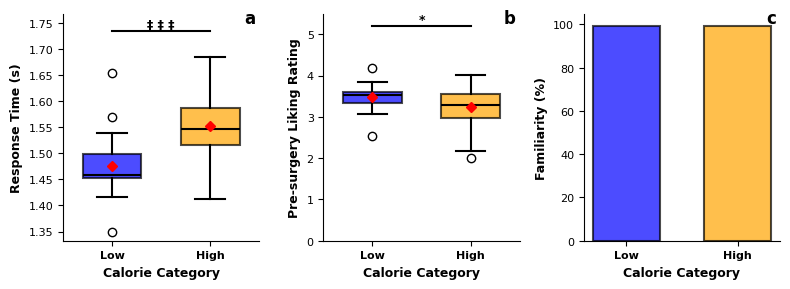


STATISTICAL TEST RESULTS: High Calorie vs Low Calorie Foods - Behavioral Properties
(Filtered to df_final participant-session combinations)
                 Property         Test Statistic p-value n_high n_low mean_high mean_low p_norm_high p_norm_low p_equal_var
        Response Time (s) Mann-Whitney   863.000  0.0000     48    22     1.552    1.475      0.5694     0.0393         N/A
Pre-surgery Liking Rating       t-test    -2.078  0.0415     48    22     3.240    3.472      0.1108     0.2790      0.0887
              Familiarity   Chi-square     1.137  0.2862  17734  8993       N/A      N/A         N/A        N/A         N/A

INTERPRETATION:
Response Time & Liking: Aggregated by picture (mean across participants/sessions)
Familiarity: Chi-square test on frequency counts (Known vs Unknown)


In [ ]:


# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')



print(f"df_final shape: {df_final.shape}")

# Create valid combinations - convert sess to string to match df session format
valid_combinations = set(
    df_final[['Subj', 'sess']].apply(lambda row: (row['Subj'].lower(), str(row['sess'])), axis=1)
)

print(f"Number of valid (participant, session) combinations in df_final: {len(valid_combinations)}")

# Define significance symbols per test type
test_symbols = {
    't-test': '*',           # Asterisk for t-test
    "Welch's t": '†',        # Dagger for Welch's t-test
    'Mann-Whitney': '‡'      # Double dagger for Mann-Whitney
}

# Filter data: FIRST filter to valid combinations from df_final
print(f"\nBefore filtering to df_final combinations: {len(df)} rows")

# Ensure session is string for comparison
df_filtered = df.copy()
df_filtered['session'] = df_filtered['session'].astype(str)

# Filter to only valid (participant, session) combinations from df_final
df_filtered = df_filtered[
    df_filtered.apply(lambda row: (row['id_participant'].lower(), str(row['session'])) in valid_combinations, axis=1)
]

print(f"After filtering to df_final combinations: {len(df_filtered)} rows")

# Keep only sessions 1-4
df_filtered = df_filtered[df_filtered['session'].isin(['1', '2', '3', '4'])]

print(f"After filtering to sessions 1-4: {len(df_filtered)} rows")
print(f"Unique participants: {df_filtered['id_participant'].nunique()}")

# Aggregate by picture for continuous variables (mean across all participants and sessions)
print("\nAggregating data by picture...")
all_properties = ['response_time', 'like']

agg_dict = {}
for prop in all_properties:
    agg_dict[prop] = 'mean'
agg_dict['calories'] = 'first'

df_agg = df_filtered.groupby('picture', as_index=False).agg(agg_dict)

print(f"Filtered data (valid combinations only): {len(df_filtered)} rows")
print(f"Aggregated data: {len(df_agg)} rows (unique pictures)")
print(f"Calories distribution: {df_agg['calories'].value_counts().to_dict()}")

# Function to perform normality test
def test_normality(data):
    """Shapiro-Wilk test for normality. Returns p-value."""
    if len(data) < 3 or len(data) > 5000:
        return np.nan
    try:
        _, p = shapiro(data)
        return p
    except:
        return np.nan

# Function to perform equality of variances test
def test_equal_variances(data1, data2):
    """Levene's test for equality of variances. Returns p-value."""
    if len(data1) < 2 or len(data2) < 2:
        return np.nan
    try:
        _, p = levene(data1, data2)
        return p
    except:
        return np.nan

# Function to determine which test to use and perform it
def perform_statistical_test(data_hi, data_lo):
    """
    Determine appropriate test based on normality and variance equality.
    Returns: (test_name, statistic, p_value, p_norm_hi, p_norm_lo, p_var)
    """
    p_norm_hi = test_normality(data_hi)
    p_norm_lo = test_normality(data_lo)
    
    print(f"  Normality test - High: p={p_norm_hi:.4f}, Low: p={p_norm_lo:.4f}")
    
    both_normal = not np.isnan(p_norm_hi) and not np.isnan(p_norm_lo) and (p_norm_hi > 0.05) and (p_norm_lo > 0.05)
    
    if both_normal:
        p_var = test_equal_variances(data_hi, data_lo)
        print(f"  Equal variance test: p={p_var:.4f}")
        
        if p_var > 0.05:
            stat, p = ttest_ind(data_hi, data_lo, equal_var=True)
            return ('t-test', stat, p, p_norm_hi, p_norm_lo, p_var)
        else:
            stat, p = ttest_ind(data_hi, data_lo, equal_var=False)
            return ("Welch's t", stat, p, p_norm_hi, p_norm_lo, p_var)
    else:
        stat, p = mannwhitneyu(data_hi, data_lo, alternative='two-sided')
        return ('Mann-Whitney', stat, p, p_norm_hi, p_norm_lo, np.nan)

# Colors for box plots
colors = {'hi': 'orange', 'lo': 'blue'}

# Store all statistical results
all_stats_results = []

# Property labels
property_labels = {
    'response_time': 'Response Time (s)',
    'like': 'Pre-surgery Liking Rating'
}

# Define y-axis limits
y_axis_limits = {
    'like': (0, 5.5)  # Extended to accommodate significance bar
}

# Define y-axis ticks
y_axis_ticks = {
    'like': [0, 1, 2, 3, 4, 5]
}

# PANEL 1 & 2: CONTINUOUS BEHAVIORAL PROPERTIES (Response Time & Liking)
print("\n" + "="*80)
print("BEHAVIORAL PROPERTIES - CONTINUOUS VARIABLES (FILTERED TO DF_FINAL COMBINATIONS)")
print("="*80)

properties = ['response_time', 'like']

for idx, prop in enumerate(properties):
    print(f"\nProcessing: {property_labels[prop]}")
    
    data = df_agg[['calories', prop]].dropna()
    
    if len(data) > 0:
        data_hi = data[data['calories'] == 'hi'][prop].values
        data_lo = data[data['calories'] == 'lo'][prop].values
        
        print(f"  n_high={len(data_hi)}, n_low={len(data_lo)}")
        
        if len(data_hi) > 0 and len(data_lo) > 0:
            test_name, stat, p_value, p_norm_hi, p_norm_lo, p_var = perform_statistical_test(data_hi, data_lo)
            
            print(f"  Test: {test_name}, p={p_value:.4f}")
            
            all_stats_results.append({
                'Property': property_labels[prop],
                'Test': test_name,
                'Statistic': f'{stat:.3f}',
                'p-value': f'{p_value:.4f}',
                'n_high': len(data_hi),
                'n_low': len(data_lo),
                'mean_high': f'{data_hi.mean():.3f}',
                'mean_low': f'{data_lo.mean():.3f}',
                'p_norm_high': f'{p_norm_hi:.4f}' if not np.isnan(p_norm_hi) else 'N/A',
                'p_norm_low': f'{p_norm_lo:.4f}' if not np.isnan(p_norm_lo) else 'N/A',
                'p_equal_var': f'{p_var:.4f}' if not np.isnan(p_var) else 'N/A'
            })

# PANEL 3: FAMILIARITY (FREQUENCY ANALYSIS)
print("\n" + "="*80)
print("FAMILIARITY FREQUENCY ANALYSIS")
print("="*80)

# Create contingency table: Known/Unknown x High/Low calories
df_filtered['is_known'] = (df_filtered['known'] == 1.0).astype(int)

contingency_table = pd.crosstab(
    df_filtered['calories'], 
    df_filtered['known'],
    margins=True,
    margins_name='Total'
)

print("\nContingency Table (Counts):")
print(contingency_table)

# Calculate percentages within each calorie category
contingency_pct = pd.crosstab(
    df_filtered['calories'], 
    df_filtered['known'],
    normalize='index'
) * 100

print("\nContingency Table (Percentages within calorie category):")
print(contingency_pct.round(2))

# Perform chi-square test
contingency_for_test = pd.crosstab(df_filtered['calories'], df_filtered['known'])
chi2, p_value_chi, dof, expected = chi2_contingency(contingency_for_test)

print(f"\n" + "="*80)
print("CHI-SQUARE TEST RESULTS")
print("="*80)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value_chi:.4f}")

if p_value_chi < 0.001:
    sig_level_chi = '***'
elif p_value_chi < 0.01:
    sig_level_chi = '**'
elif p_value_chi < 0.05:
    sig_level_chi = '*'
else:
    sig_level_chi = 'n.s.'

print(f"Significance: {sig_level_chi}")

# Add to results
all_stats_results.append({
    'Property': 'Familiarity',
    'Test': 'Chi-square',
    'Statistic': f'{chi2:.3f}',
    'p-value': f'{p_value_chi:.4f}',
    'n_high': f"{df_filtered[df_filtered['calories'] == 'hi'].shape[0]}",
    'n_low': f"{df_filtered[df_filtered['calories'] == 'lo'].shape[0]}",
    'mean_high': 'N/A',
    'mean_low': 'N/A',
    'p_norm_high': 'N/A',
    'p_norm_low': 'N/A',
    'p_equal_var': 'N/A'
})

# CREATE FIGURE 3: BEHAVIORAL PROPERTIES (3 panels)
print("\n" + "="*80)
print("FIGURE 3: BEHAVIORAL PROPERTIES (FILTERED TO DF_FINAL COMBINATIONS)")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(8, 3))

# PANEL 1 & 2: Box plots for continuous variables
for idx, prop in enumerate(['response_time', 'like']):
    ax = axes[idx]
    
    data = df_agg[['calories', prop]].dropna()
    
    if len(data) > 0:
        data_hi = data[data['calories'] == 'hi'][prop].values
        data_lo = data[data['calories'] == 'lo'][prop].values
        
        # Get test results from earlier
        result = [r for r in all_stats_results if r['Property'] == property_labels[prop]][0]
        p_value = float(result['p-value'])
        test_name = result['Test']
        
        box_data = [data_lo, data_hi]
        
        bp = ax.boxplot(box_data, positions=[0, 1], widths=0.6,
                       patch_artist=True, showmeans=True,
                       meanprops=dict(marker='D', markerfacecolor='red', markeredgecolor='red', markersize=5),
                       medianprops=dict(color='black', linewidth=1.5),
                       boxprops=dict(linewidth=1.5),
                       whiskerprops=dict(linewidth=1.5),
                       capprops=dict(linewidth=1.5))
        
        bp['boxes'][0].set_facecolor(colors['lo'])
        bp['boxes'][0].set_alpha(0.7)
        bp['boxes'][1].set_facecolor(colors['hi'])
        bp['boxes'][1].set_alpha(0.7)
        
        # Determine significance marker
        base_symbol = test_symbols.get(test_name, '*')
        
        if p_value < 0.001:
            sig_marker = ' '.join([base_symbol] * 3)
        elif p_value < 0.01:
            sig_marker = ' '.join([base_symbol] * 2)
        elif p_value < 0.05:
            sig_marker = base_symbol
        else:
            sig_marker = 'n.s.'
        
        # Set y-limits and add significance bar
        if prop in y_axis_limits:
            y_min, y_max = y_axis_limits[prop]
            ax.set_ylim(y_min, y_max)
            
            # Add significance bar for fixed limits if significant
            if p_value < 0.05:
                y_bar = 5.2  # Position for significance bar
                ax.plot([0, 1], [y_bar, y_bar], 'k-', linewidth=1.5)
                ax.text(0.5, y_bar, sig_marker, ha='center', va='bottom', fontsize=9, fontweight='bold')
        else:
            y_max = max(data_hi.max(), data_lo.max())
            y_min = min(data_hi.min(), data_lo.min())
            y_range = y_max - y_min
            
            # Add significance bar for dynamic limits
            if p_value < 0.05:
                y_bar = y_max + 0.15 * y_range
                ax.plot([0, 1], [y_bar, y_bar], 'k-', linewidth=1.5)
                ax.text(0.5, y_bar, sig_marker, ha='center', va='bottom', fontsize=9, fontweight='bold')
                ax.set_ylim(y_min - 0.05 * y_range, y_max + 0.25 * y_range)
        
        # Set y-axis ticks
        if prop in y_axis_ticks:
            ax.set_yticks(y_axis_ticks[prop])
        
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Low', 'High'], fontsize=8, fontweight='bold')
        ax.set_xlabel('Calorie Category', fontsize=9, fontweight='bold')
        ax.set_ylabel(property_labels[prop], fontsize=9, fontweight='bold')
        ax.tick_params(axis='y', which='major', labelsize=8)
        
        ax.text(0.98, 1.02, chr(97 + idx), transform=ax.transAxes,
                fontsize=12, fontweight='bold', va='top', ha='right')
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

# PANEL 3: Familiarity - Known only
ax = axes[2]

# Get percentages for "Known" (value = 1.0) only
known_hi_pct = (df_filtered[(df_filtered['calories'] == 'hi') & (df_filtered['known'] == 1.0)].shape[0] / 
                df_filtered[df_filtered['calories'] == 'hi'].shape[0] * 100)

known_lo_pct = (df_filtered[(df_filtered['calories'] == 'lo') & (df_filtered['known'] == 1.0)].shape[0] / 
                df_filtered[df_filtered['calories'] == 'lo'].shape[0] * 100)

# Create simple bar chart
bar_data = [known_lo_pct, known_hi_pct]
bar_colors = [colors['lo'], colors['hi']]

bars = ax.bar([0, 1], bar_data, width=0.6, 
              color=bar_colors, alpha=0.7, 
              edgecolor='black', linewidth=1.5)

# Customize plot
ax.set_ylabel('Familiarity (%)', fontsize=9, fontweight='bold')
ax.set_xlabel('Calorie Category', fontsize=9, fontweight='bold')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Low', 'High'], fontsize=8, fontweight='bold')
ax.set_ylim(0, 105)
ax.tick_params(axis='y', which='major', labelsize=8)

# Add panel label
ax.text(0.98, 1.02, 'c', transform=ax.transAxes,
        fontsize=12, fontweight='bold', va='top', ha='right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Print comprehensive statistical results table
print("\n" + "="*120)
print("STATISTICAL TEST RESULTS: High Calorie vs Low Calorie Foods - Behavioral Properties")
print("(Filtered to df_final participant-session combinations)")
print("="*120)

stats_df = pd.DataFrame(all_stats_results)
print(stats_df.to_string(index=False))

print("\n" + "="*120)
print("INTERPRETATION:")
print("="*120)
print("Response Time & Liking: Aggregated by picture (mean across participants/sessions)")
print("Familiarity: Chi-square test on frequency counts (Known vs Unknown)")
print("="*120)